#AdEase - Website Views Forecasting for Ad placement(Time Series Analysis)
Ad Ease is an ads and marketing based company helping businesses elicit maximum clicks @ minimum cost. AdEase is an ad infrastructure to help businesses promote themselves easily, effectively, and economically. The interplay of 3 AI modules - Design, Dispense, and Decipher, come together to make it this an end-to-end 3 step process digital advertising solution for all.

You are working in the Data Science team of Ad ease trying to understand the per page view report for different wikipedia pages for 550 days, and forecasting the number of views so that you can predict and optimize the ad placement for your clients. You are provided with the data of 145k wikipedia pages and daily view count for each of them. Your clients belong to different regions and need data on how their ads will perform on pages in different languages.

#Import Libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
pd.set_option('display.max_colwidth', None)
plt.rcParams['figure.figsize'] = (12, 6)

#Load Dataset

In [3]:
!gdown 1qQkymAitU6l2pSe702rDUhQpoP8MUZXl
!gdown 19qvuu7E8yD63o4WkOdy_lLFSrZlZPpuE

Downloading...
From (original): https://drive.google.com/uc?id=1qQkymAitU6l2pSe702rDUhQpoP8MUZXl
From (redirected): https://drive.google.com/uc?id=1qQkymAitU6l2pSe702rDUhQpoP8MUZXl&confirm=t&uuid=3e476258-94ba-49fe-a70a-a83bb0b5176e
To: /content/train_1.csv
100% 278M/278M [00:04<00:00, 66.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=19qvuu7E8yD63o4WkOdy_lLFSrZlZPpuE
To: /content/Exog_Campaign_eng
100% 1.10k/1.10k [00:00<00:00, 3.55MB/s]


In [4]:
df = pd.read_csv('train_1.csv')
ex = pd.read_csv('Exog_Campaign_eng')

Data Dictionary:

There are two csv files given

- train_1.csv: In the csv file, each row corresponds to a particular article and each column corresponds to a particular date. The values are the number of visits on that date.

    The page name contains data in this format:

    SPECIFIC NAME _ LANGUAGE.wikipedia.org _ ACCESS TYPE _ ACCESS ORIGIN

    having information about the page name, the main domain, the device type used to access the page, and also the request origin(spider or browser agent)


- Exog_Campaign_eng: This file contains data for the dates which had a campaign or significant event that could affect the views for that day. The data is just for pages in English.

    There's 1 for dates with campaigns and 0 for remaining dates. It is to be treated as an exogenous variable for models when training and forecasting data for pages in English

#EDA

In [5]:
df.shape, ex.shape

((145063, 551), (550, 1))

In [6]:
df

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,13.0,12.0,13.0,3.0,5.0,10.0
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145061,Hasta_el_último_hombre_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Obervations
    - Data has 145k articles and 550 days data.
    - Date range is from 2015-07-01 till 2016-12-31.

In [7]:
ex

,Exog
0,0
1,0
2,0
3,0
4,0
...,...
545,1
546,1
547,1
548,0


In [8]:
df['Page']

,Page
0,2NE1_zh.wikipedia.org_all-access_spider
1,2PM_zh.wikipedia.org_all-access_spider
2,3C_zh.wikipedia.org_all-access_spider
3,4minute_zh.wikipedia.org_all-access_spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_spider
...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.org_all-access_spider
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org_all-access_spider
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-access_spider
145061,Hasta_el_último_hombre_es.wikipedia.org_all-access_spider


The page name contains data in this format:

SPECIFIC NAME _ LANGUAGE.wikipedia.org _ ACCESS TYPE _ ACCESS ORIGIN

having information about the page name, the main domain, the device type used to access the page, and also the request origin(spider or browser agent)

In [9]:
df['Page'][4]

'52_Hz_I_Love_You_zh.wikipedia.org_all-access_spider'

In [10]:
df['Page'][145062]

'Francisco_el_matemático_(serie_de_televisión_de_2017)_es.wikipedia.org_all-access_spider'

In [11]:
pattern = r'^(.+?)_([a-z]{2,3})\.wikipedia\.org_([^_]+)_([^_]+)$'

df[['title', 'lang', 'access_type', 'access_origin']] = df['Page'].str.extract(pattern)

df

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,title,lang,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,zh,all-access,spider
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.0,12.0,13.0,3.0,5.0,10.0,Underworld_(serie_de_películas),es,all-access,spider
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Resident_Evil:_Capítulo_Final,es,all-access,spider
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Enamorándome_de_Ramón,es,all-access,spider
145061,Hasta_el_último_hombre_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Hasta_el_último_hombre,es,all-access,spider


In [12]:
df['lang'].value_counts(normalize=True, dropna=False)*100

,proportion
lang,
en,16.618986
ja,14.084225
de,12.785479
NaN,12.308445
fr,12.271909
zh,11.876909
ru,10.355501
es,9.698545


In [13]:
df['access_type'].value_counts(normalize=True, dropna=False)*100

,proportion
access_type,
all-access,45.299628
mobile-web,21.316945
desktop,21.074981
NaN,12.308445


In [14]:
df['access_origin'].value_counts(normalize=True, dropna=False)*100

,proportion
access_origin,
all-agents,66.587621
spider,21.103934
NaN,12.308445


In [15]:
mask = df['title'].isna()

split_cols = (
    df.loc[mask, 'Page']
      .str.rsplit('_', n=3, expand=True)
)

df.loc[mask, 'access_type'] = split_cols[2]
df.loc[mask, 'access_origin'] = split_cols[3]
df.loc[mask, 'title'] = split_cols[0]

In [16]:
df[df['lang'].isna()].sample(10)

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,title,lang,access_type,access_origin
19787,File:MediaWiki_logo.png_www.mediawiki.org_all-access_all-agents,17.0,11.0,14.0,12.0,23.0,14.0,15.0,18.0,16.0,...,3.0,9.0,19.0,14.0,14.0,14.0,File:MediaWiki_logo.png,NaN,all-access,all-agents
23207,Wikimedia_Hackathon_BPHC_www.mediawiki.org_mobile-web_all-agents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,1.0,Wikimedia_Hackathon_BPHC,NaN,mobile-web,all-agents
44777,"File:Official_Presidential_portrait_of_Thomas_Jefferson_(by_Rembrandt_Peale,_1800).jpg_commons.wikimedia.org_all-access_all-agents",9.0,13.0,14.0,16.0,22.0,10.0,10.0,11.0,9.0,...,11.0,7.0,8.0,13.0,12.0,13.0,"File:Official_Presidential_portrait_of_Thomas_Jefferson_(by_Rembrandt_Peale,_1800).jpg",NaN,all-access,all-agents
79602,File:Siege_of_Sidney_Street_4d.JPG_commons.wikimedia.org_mobile-web_all-agents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,File:Siege_of_Sidney_Street_4d.JPG,NaN,mobile-web,all-agents
45238,Category:Lesbian_porn_actresses_commons.wikimedia.org_all-access_all-agents,95.0,99.0,81.0,83.0,97.0,101.0,91.0,105.0,111.0,...,172.0,209.0,188.0,214.0,248.0,160.0,Category:Lesbian_porn_actresses,NaN,all-access,all-agents
44172,Category:Porn_actresses_from_Michigan_commons.wikimedia.org_all-access_all-agents,68.0,37.0,27.0,61.0,54.0,55.0,45.0,36.0,46.0,...,20.0,31.0,26.0,31.0,35.0,16.0,Category:Porn_actresses_from_Michigan,NaN,all-access,all-agents
83780,Topic:T2szzp4bocj97lno_www.mediawiki.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,Topic:T2szzp4bocj97lno,NaN,all-access,spider
45974,File:Flag_of_Turkey.svg_commons.wikimedia.org_all-access_all-agents,176.0,549.0,332.0,207.0,144.0,199.0,167.0,155.0,184.0,...,119.0,288.0,124.0,144.0,123.0,128.0,File:Flag_of_Turkey.svg,NaN,all-access,all-agents
83294,Help:Patrolled_edits_www.mediawiki.org_all-access_spider,10.0,12.0,12.0,34.0,78.0,77.0,76.0,32.0,2.0,...,8.0,9.0,6.0,9.0,11.0,10.0,Help:Patrolled_edits,NaN,all-access,spider
82893,File:Eugène_Delacroix_-_La_liberté_guidant_le_peuple.jpg_commons.wikimedia.org_desktop_all-agents,85.0,102.0,83.0,66.0,57.0,79.0,97.0,68.0,155.0,...,65.0,91.0,64.0,77.0,59.0,69.0,File:Eugène_Delacroix_-_La_liberté_guidant_le_peuple.jpg,NaN,desktop,all-agents


In [17]:
df['lang'].value_counts(dropna=False)

,count
lang,
en,24108
ja,20431
de,18547
NaN,17855
fr,17802
zh,17229
ru,15022
es,14069


In [18]:
df['lang'].value_counts(normalize=True, dropna=False)*100

,proportion
lang,
en,16.618986
ja,14.084225
de,12.785479
NaN,12.308445
fr,12.271909
zh,11.876909
ru,10.355501
es,9.698545


In [19]:
df['lang'] = df['lang'].fillna('No Language')

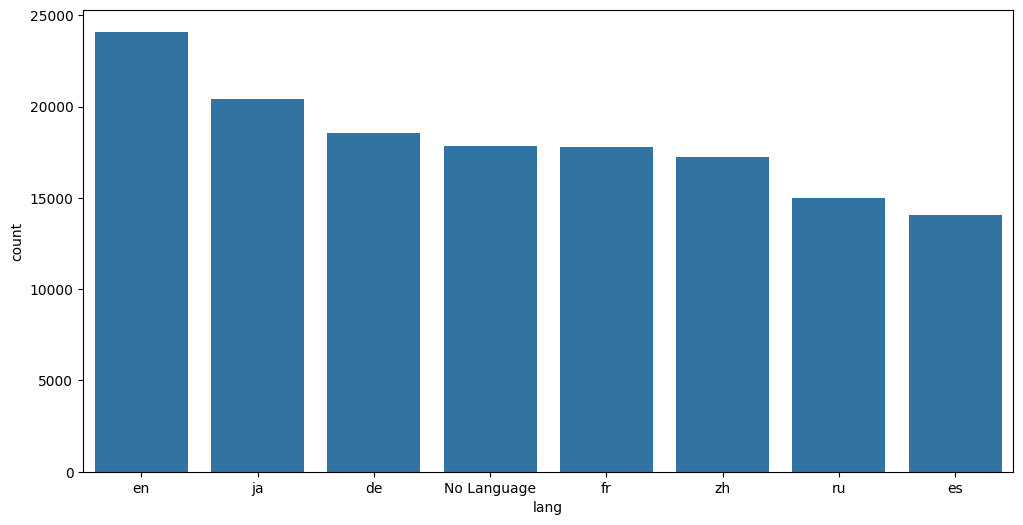

In [20]:
order = df['lang'].value_counts().index

sns.countplot(
    x=df['lang'],
    order=order
)

plt.show()

In [21]:
df['access_type'].value_counts(normalize=True, dropna=False)*100

,proportion
access_type,
all-access,51.229466
mobile-web,24.774753
desktop,23.995781


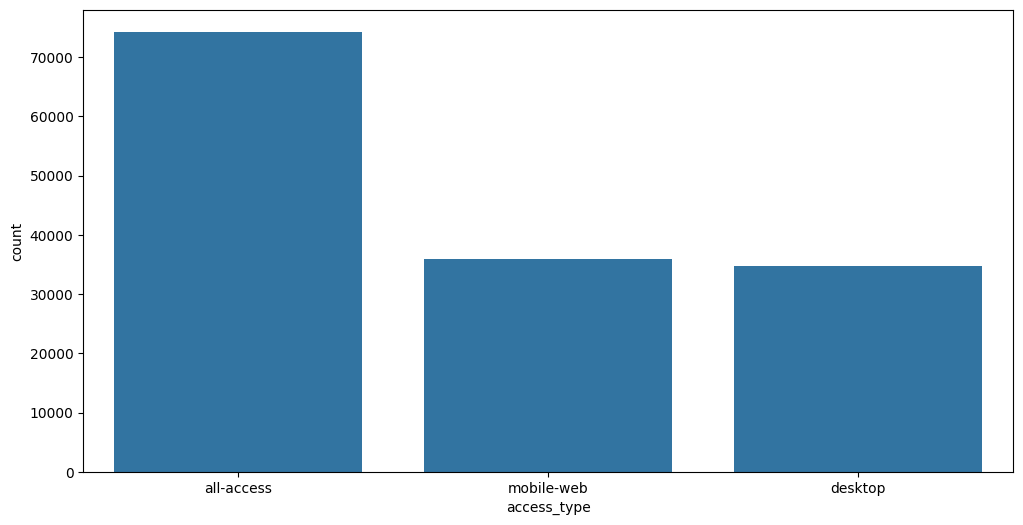

In [22]:
order = df['access_type'].value_counts().index

sns.countplot(
    x=df['access_type'],
    order=order
)

plt.show()

In [23]:
df['access_origin'].value_counts(normalize=True, dropna=False)*100

,proportion
access_origin,
all-agents,75.932526
spider,24.067474


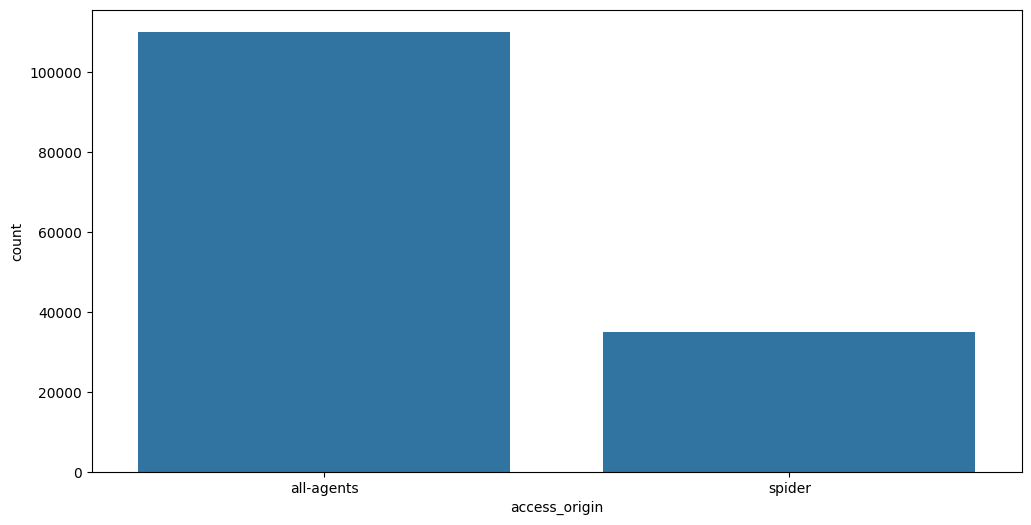

In [24]:
order = df['access_origin'].value_counts().index

sns.countplot(
    x=df['access_origin'],
    order=order
)

plt.show()

* Observations
    - `en` language has highest article with 24k counts, where `es` is lowest with 14k counts.
    - Most articles are `all-access` type.
    - `all-agent` origin has highest count approx. 110k.

In [25]:
df.isna().sum()

,0
Page,0
2015-07-01,20740
2015-07-02,20816
2015-07-03,20544
2015-07-04,20654
...,...
2016-12-31,3465
title,0
lang,0
access_type,0


Requiered Nulls are imputed with new category, the nulls that are under dates simply means no visits to the pages on that particular day, so can impute with 0 but, agg will hangle it so ignoring imputaiton

In [26]:
df

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,title,lang,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,zh,all-access,spider
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.0,12.0,13.0,3.0,5.0,10.0,Underworld_(serie_de_películas),es,all-access,spider
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Resident_Evil:_Capítulo_Final,es,all-access,spider
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Enamorándome_de_Ramón,es,all-access,spider
145061,Hasta_el_último_hombre_es.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Hasta_el_último_hombre,es,all-access,spider


`all-access ≈ mobile-web + desktop + etc.`

Therefore:

summing them together would cause double counting, and using both aggregate + component series in modeling can bias results.

`all-agents` is an aggregate category that already includes:
 - human/user traffic,
 - spider traffic (bots/crawlers).

So:

`all-agents ≈ human traffic + spider traffic`

This means:

spider is not separate from all-agents,
combining them directly would double count traffic.

So, we will only keep all-access, and from these we will subtract spider traffics from all agents to to get Human traffic data. Because we need to show humans ad not the bots.

In [27]:
df.shape

(145063, 555)

In [28]:
df.columns

Index(['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04',
       '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08', '2015-07-09',
       ...
       '2016-12-26', '2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30',
       '2016-12-31', 'title', 'lang', 'access_type', 'access_origin'],
      dtype='object', length=555)

#Extracting Real-Human Traffic from dataset for modeling

In [29]:
# Date columns
date_cols = df.columns[1:551]

# Keep only all-access rows
df_access = df[df['access_type'] == 'all-access'].copy()

# Separate all-agents and spider
all_agents = df_access[df_access['access_origin'] == 'all-agents'].copy()
spider = df_access[df_access['access_origin'] == 'spider'].copy()

# Merge
merged = all_agents.merge(
    spider[['title', 'lang'] + list(date_cols)],
    on=['title', 'lang'],
    suffixes=('_all', '_spider')
)

# Vectorized subtraction of all-agents and spiders
human_traffic = (
    merged[[f'{c}_all' for c in date_cols]].values
    - merged[[f'{c}_spider' for c in date_cols]].values
)

# Final dataframe
final_df = pd.concat([
    merged[['title', 'lang']].reset_index(drop=True),
    pd.DataFrame(human_traffic, columns=date_cols)
], axis=1)

final_df.shape

(34967, 552)

In [30]:
final_df.drop(columns=['title'], inplace=True)
final_df

,lang,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,No Language,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.0,17.0,9.0,15.0,11.0,14.0,10.0,13.0,6.0,11.0
1,No Language,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,73.0,36.0,31.0,26.0,15.0,28.0,39.0,33.0,44.0,45.0
2,No Language,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.0,21.0,25.0,11.0,12.0,27.0,30.0,24.0,22.0,14.0
3,No Language,504.0,556.0,603.0,452.0,472.0,543.0,600.0,587.0,554.0,...,448.0,275.0,195.0,203.0,255.0,367.0,307.0,316.0,330.0,250.0
4,No Language,28.0,27.0,33.0,18.0,26.0,45.0,54.0,44.0,35.0,...,40.0,28.0,15.0,14.0,14.0,24.0,26.0,15.0,28.0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34962,de,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23007.0,20407.0,7287.0,5099.0,2838.0,3571.0,2880.0,2823.0,3102.0,1339.0
34963,de,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,133.0,180.0,275.0,342.0,550.0,394.0
34964,de,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,42.0,94.0,56.0,24.0,14.0,7.0
34965,de,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,12123.0,38911.0,13845.0,27834.0,12675.0,4081.0


Now rows have reduced to apprx. 35k(Human trafics) from 145k(Human+bot traffics).

This gives:

only `all-access` traffic, with estimated human traffic i.e.

    Human Traffic = all-agents - spider

In [31]:
df_lang = final_df.groupby('lang').sum().T
df_lang

lang,No Language,de,en,es,fr,ja,ru,zh
2015-07-01,895740.0,6639841.0,41794296.0,7454467.0,4155232.0,5829541.0,4646140.0,1983860.0
2015-07-02,894970.0,6536940.0,41716019.0,7126580.0,4229778.0,7138009.0,4743744.0,2011522.0
2015-07-03,837027.0,6305645.0,39667707.0,6572256.0,4032889.0,6120332.0,4390050.0,1998912.0
2015-07-04,695100.0,5803849.0,41471104.0,6182435.0,4309426.0,7643433.0,4123971.0,2010344.0
2015-07-05,744684.0,6763251.0,42884745.0,6729170.0,4253485.0,7350451.0,4401659.0,2132631.0
...,...,...,...,...,...,...,...,...
2016-12-27,1660797.0,10800962.0,72293618.0,6516270.0,6528622.0,7306039.0,7337919.0,3122502.0
2016-12-28,2439835.0,10214906.0,70559850.0,6638552.0,6805224.0,7299572.0,6833528.0,3118845.0
2016-12-29,1732255.0,9802658.0,75010915.0,6534378.0,6598528.0,8014933.0,6555439.0,2870709.0
2016-12-30,2010062.0,9333732.0,62638944.0,5529702.0,6079342.0,8808242.0,5812242.0,2910013.0


In [32]:
df_lang.index = pd.to_datetime(df_lang.index)
df_lang

lang,No Language,de,en,es,fr,ja,ru,zh
2015-07-01,895740.0,6639841.0,41794296.0,7454467.0,4155232.0,5829541.0,4646140.0,1983860.0
2015-07-02,894970.0,6536940.0,41716019.0,7126580.0,4229778.0,7138009.0,4743744.0,2011522.0
2015-07-03,837027.0,6305645.0,39667707.0,6572256.0,4032889.0,6120332.0,4390050.0,1998912.0
2015-07-04,695100.0,5803849.0,41471104.0,6182435.0,4309426.0,7643433.0,4123971.0,2010344.0
2015-07-05,744684.0,6763251.0,42884745.0,6729170.0,4253485.0,7350451.0,4401659.0,2132631.0
...,...,...,...,...,...,...,...,...
2016-12-27,1660797.0,10800962.0,72293618.0,6516270.0,6528622.0,7306039.0,7337919.0,3122502.0
2016-12-28,2439835.0,10214906.0,70559850.0,6638552.0,6805224.0,7299572.0,6833528.0,3118845.0
2016-12-29,1732255.0,9802658.0,75010915.0,6534378.0,6598528.0,8014933.0,6555439.0,2870709.0
2016-12-30,2010062.0,9333732.0,62638944.0,5529702.0,6079342.0,8808242.0,5812242.0,2910013.0


In [33]:
df_lang.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 550 entries, 2015-07-01 to 2016-12-31
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No Language  550 non-null    float64
 1   de           550 non-null    float64
 2   en           550 non-null    float64
 3   es           550 non-null    float64
 4   fr           550 non-null    float64
 5   ja           550 non-null    float64
 6   ru           550 non-null    float64
 7   zh           550 non-null    float64
dtypes: float64(8)
memory usage: 38.7 KB


In [34]:
df_lang.describe().T

,count,mean,std,min,25%,50%,75%,max
lang,,,,,,,,
No Language,550.0,1.354348e+06,5.193579e+05,663792.0,992419.50,1201631.5,1604139.00,5071106.0
de,550.0,7.882375e+06,9.794314e+05,5674841.0,7201692.50,7727883.5,8420701.00,12066430.0
en,550.0,5.159838e+07,1.129305e+07,37795079.0,44239958.75,48848410.5,54994173.75,99287854.0
es,550.0,8.348191e+06,1.638853e+06,4285024.0,7099753.50,8310458.0,9837146.25,14646228.0
fr,550.0,5.500847e+06,8.704953e+05,3420755.0,5007423.50,5436657.5,5918064.25,9680880.0
ja,550.0,7.109083e+06,1.019268e+06,4385568.0,6395625.00,7077736.5,7733054.75,13231308.0
ru,550.0,7.071115e+06,2.845075e+06,3671986.0,5951262.25,6607522.0,7169912.50,22074111.0
zh,550.0,2.750873e+06,4.716030e+05,1482175.0,2354035.75,2817210.5,3061145.75,5284976.0


Traffic Summary by Language
- English (en) has the highest average daily traffic (~51.6M views), significantly higher than all other languages.
- Spanish (es) and German (de) follow with ~8M daily views.
- Russian (ru) shows the highest variability, indicating more volatile traffic patterns.
- Chinese (zh) and "No Language" pages have comparatively lower traffic volumes.
- Most languages show consistent median and quartile values, suggesting relatively stable traffic behavior over time.

In [35]:
df_lang.sum(axis=0).sort_values(ascending=False)

,0
lang,
en,2.837911e+10
es,4.591505e+09
de,4.335306e+09
ja,3.909996e+09
ru,3.889113e+09
fr,3.025466e+09
zh,1.512980e+09
No Language,7.448916e+08


Human Traffic by Language
 - English (en) dominates with ~28.4B human page views.
 - Spanish (es), German (de), Japanese (ja), and Russian (ru) form the next major traffic groups with ~3.9–4.6B views.
 - French (fr) shows moderate traffic (~3.0B).
 - Chinese (zh) and “No Language” pages have the lowest human traffic volumes.

Inference

- English pages provide the largest monetizable audience for ad placement, while other languages offer strong regional targeting opportunities.

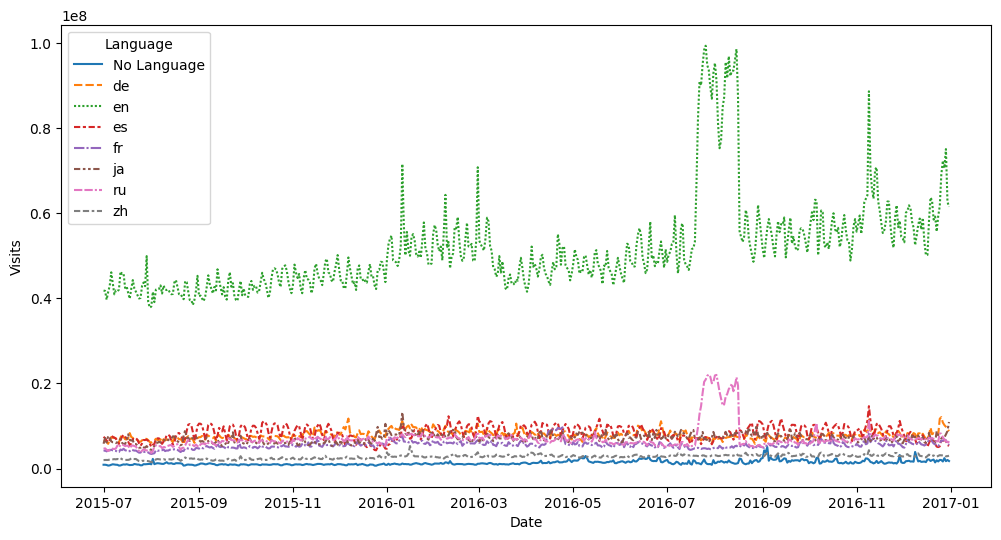

In [36]:
# Create figure
plt.figure(figsize=(12, 6))

# Plot
sns.lineplot(data=df_lang)

# Labels
plt.xlabel("Date")
plt.ylabel("Visits")

# Legend title
plt.legend(title="Language")

# Show
plt.show()

Observations
- `en` language has most number of views and there are some spikes at differnt times.
- There are some flat trends for some languages.

In [37]:
df_lang.rename(columns={'No Language': 'no_lang'}, inplace=True)

In [38]:
df_lang.columns

Index(['no_lang', 'de', 'en', 'es', 'fr', 'ja', 'ru', 'zh'], dtype='object', name='lang')

In [39]:
df_en = df_lang['en'].rename('visits_count')

In [40]:
df_en

,visits_count
2015-07-01,41794296.0
2015-07-02,41716019.0
2015-07-03,39667707.0
2015-07-04,41471104.0
2015-07-05,42884745.0
...,...
2016-12-27,72293618.0
2016-12-28,70559850.0
2016-12-29,75010915.0
2016-12-30,62638944.0


In [41]:
df_en.isna().sum()

np.int64(0)

In [42]:
ex.index = df_en.index
df_en = pd.concat([df_en, ex], axis=1)
df_en.rename(columns = {'Exog': 'ex'}, inplace=True)
df_en

,visits_count,ex
2015-07-01,41794296.0,0
2015-07-02,41716019.0,0
2015-07-03,39667707.0,0
2015-07-04,41471104.0,0
2015-07-05,42884745.0,0
...,...,...
2016-12-27,72293618.0,1
2016-12-28,70559850.0,1
2016-12-29,75010915.0,1
2016-12-30,62638944.0,0


In [43]:
np.sum(df_en['ex'] != ex['Exog'])

np.int64(0)

> **This is `df_en` is out final train_data for training model**

In [44]:
pd.infer_freq(df_en.index)

'D'

In [45]:
df_en.index.freq

In [46]:
df_en = df_en.asfreq('D')

In [47]:
df_en.index.freq

<Day>

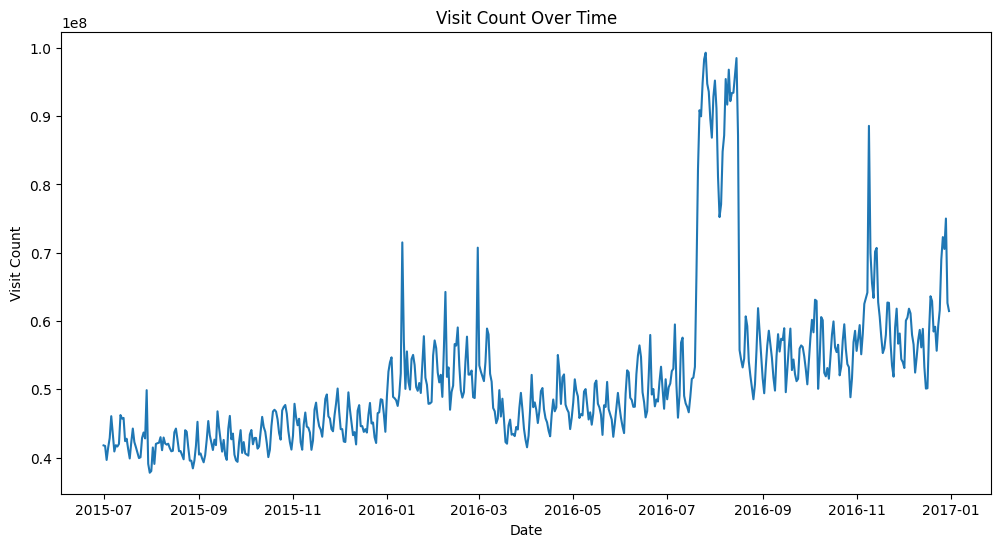

In [49]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_en,
    x=df_en.index,
    y='visits_count'
)

plt.xlabel("Date")
plt.ylabel("Visit Count")
plt.title("Visit Count Over Time")

plt.show()

#Decomposing the time-series

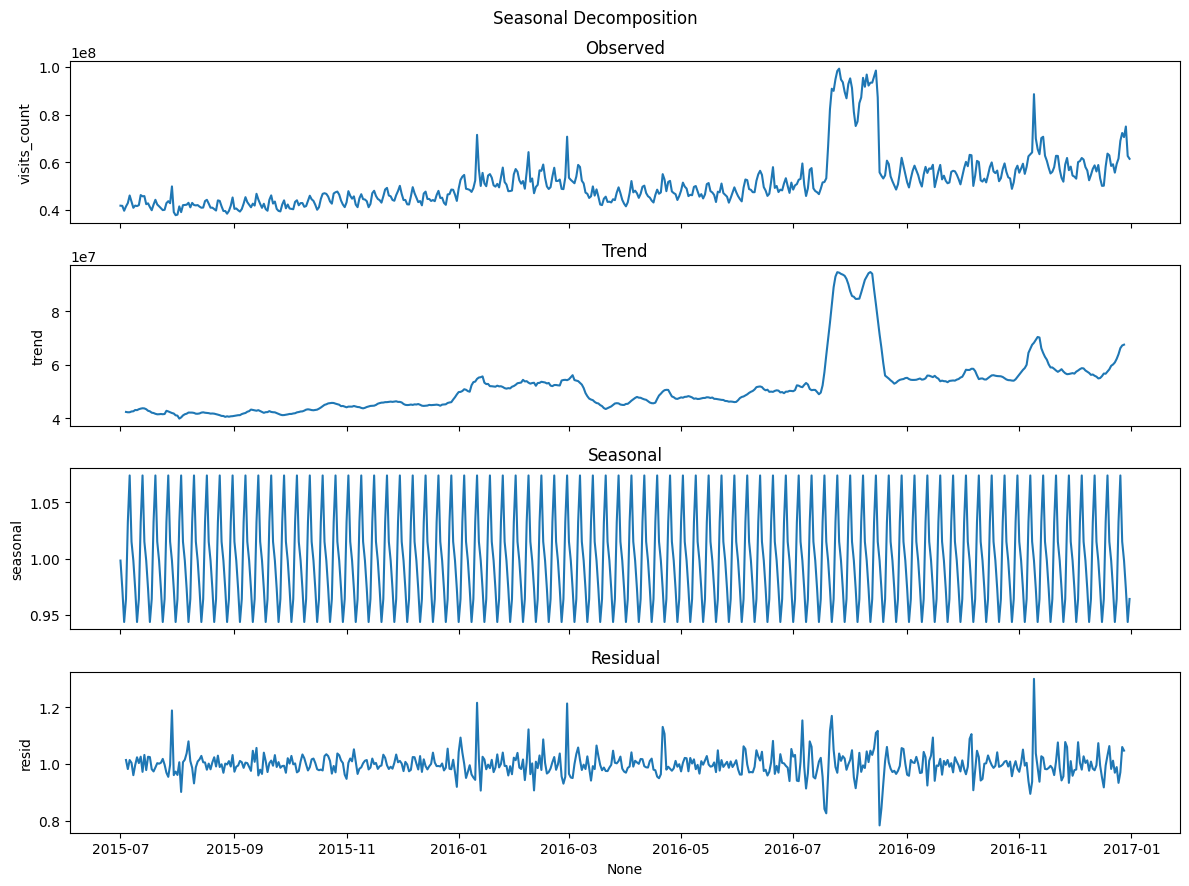

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose
decomposed = seasonal_decompose(
    df_en['visits_count'],
    model='multiplicative',
    period=7
)


fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(12, 9),
    sharex=True
)

sns.lineplot(
    x=df_en.index,
    y=decomposed.observed,
    ax=axes[0]
)
axes[0].set_title("Observed")

sns.lineplot(
    x=df_en.index,
    y=decomposed.trend,
    ax=axes[1]
)
axes[1].set_title("Trend")

sns.lineplot(
    x=df_en.index,
    y=decomposed.seasonal,
    ax=axes[2]
)
axes[2].set_title("Seasonal")

sns.lineplot(
    x=df_en.index,
    y=decomposed.resid,
    ax=axes[3]
)
axes[3].set_title("Residual")

fig.suptitle("Seasonal Decomposition")

plt.tight_layout()

plt.show()

#Train-Test Split

In [51]:
split_idx = int(len(df_en) * 0.85)

train = df_en.iloc[:split_idx]
test = df_en.iloc[split_idx:]

print(train.shape)
print(test.shape)

(467, 2)
(83, 2)


<Axes: >

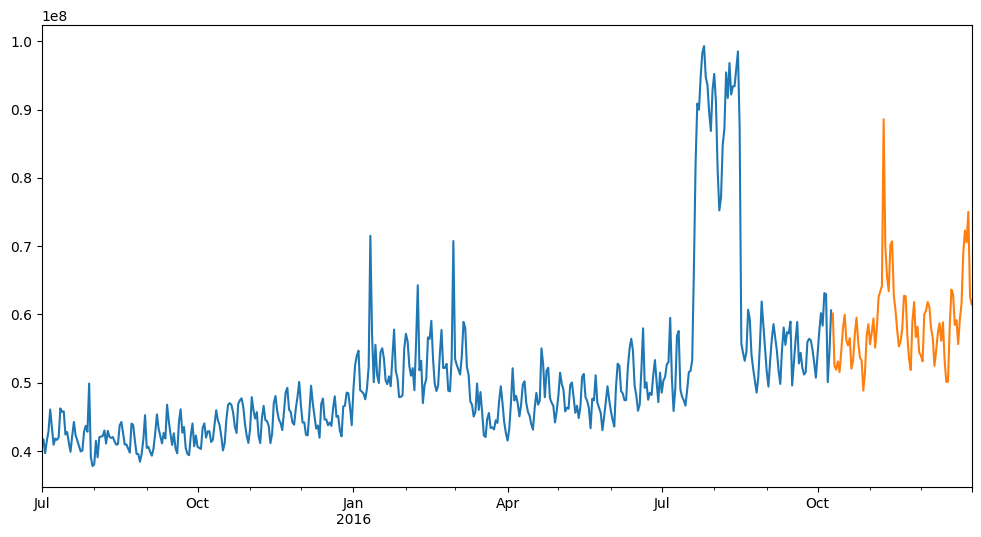

In [52]:
train.visits_count.plot()
test.visits_count.plot()

#Stationariry Check(ADF test)

In [53]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.dropna())

    print('Augmented Dickey-Fuller Test\n')

    print('H0: Series is non-stationary')
    print('H1: Series is stationary\n')

    labels = [
        'ADF Statistic',
        'p-value',
        'No. of Lags Used',
        'Number of Observations Used'
    ]

    for value, label in zip(result[:4], labels):
        print(f'{label}: {value}')

    print('\nCritical Values:')
    for key, value in result[4].items():
        print(f'{key}: {value}')

    print('\nConclusion:')

    if result[1] <= 0.05:
        print('Reject H0')
        print('Series is stationary')
    else:
        print('Fail to reject H0')
        print('Series is non-stationary')

In [54]:
adf_test(train.visits_count)

Augmented Dickey-Fuller Test

H0: Series is non-stationary
H1: Series is stationary

ADF Statistic: -2.671783161503946
p-value: 0.07904957602152218
No. of Lags Used: 16
Number of Observations Used: 450

Critical Values:
1%: -3.444965543297668
5%: -2.8679842369272976
10%: -2.5702025382716047

Conclusion:
Fail to reject H0
Series is non-stationary


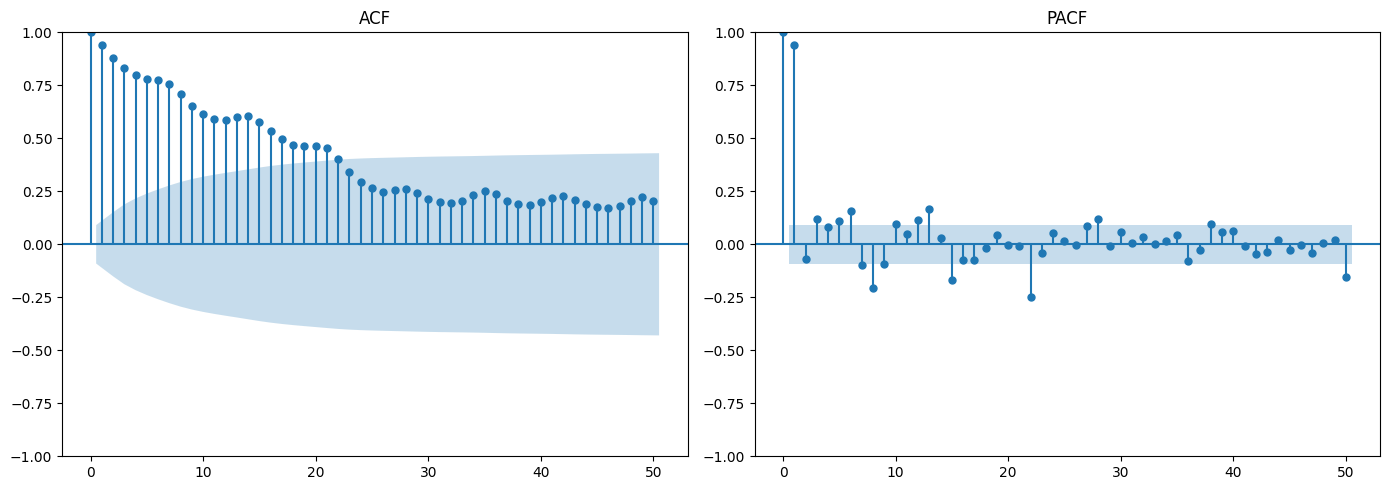

In [55]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Plot ACF/PACF
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(train.visits_count, lags=50, ax=axes[0])
plot_pacf(train.visits_count, lags=50, ax=axes[1])

axes[0].set_title('ACF')
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

#ARIMA

<Axes: >

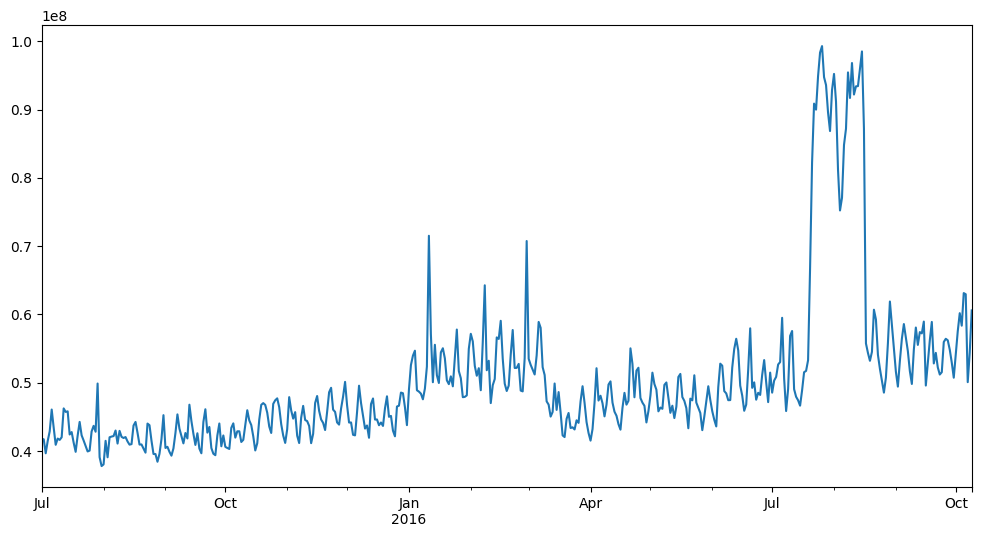

In [56]:
train.visits_count.plot()

In [57]:
adf_test(train.visits_count.dropna())

Augmented Dickey-Fuller Test

H0: Series is non-stationary
H1: Series is stationary

ADF Statistic: -2.671783161503946
p-value: 0.07904957602152218
No. of Lags Used: 16
Number of Observations Used: 450

Critical Values:
1%: -3.444965543297668
5%: -2.8679842369272976
10%: -2.5702025382716047

Conclusion:
Fail to reject H0
Series is non-stationary


<Axes: >

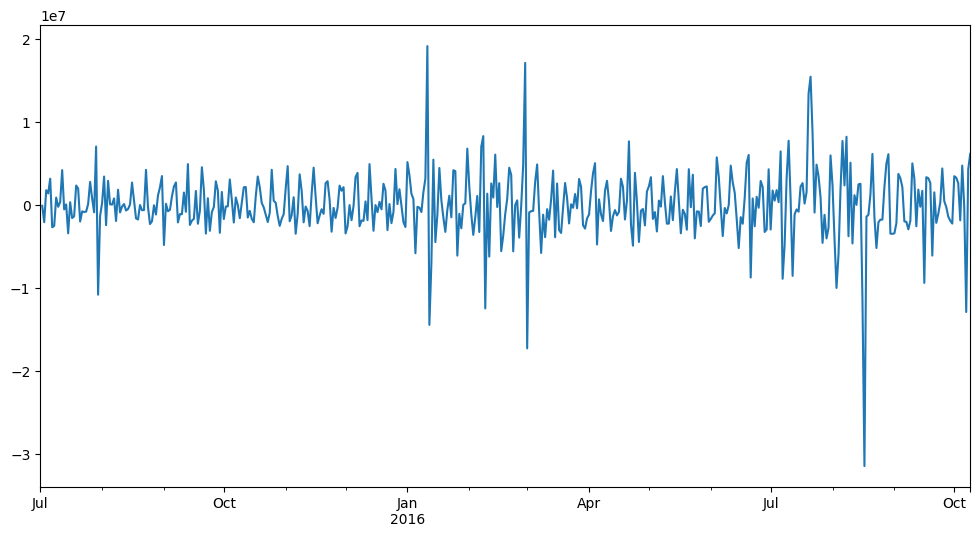

In [58]:
train.visits_count.diff(1).plot()

In [59]:
adf_test(train.visits_count.diff(1).dropna())

Augmented Dickey-Fuller Test

H0: Series is non-stationary
H1: Series is stationary

ADF Statistic: -6.688670224317289
p-value: 4.163023398046384e-09
No. of Lags Used: 13
Number of Observations Used: 452

Critical Values:
1%: -3.444900499925237
5%: -2.8679556266351653
10%: -2.570187288941969

Conclusion:
Reject H0
Series is stationary


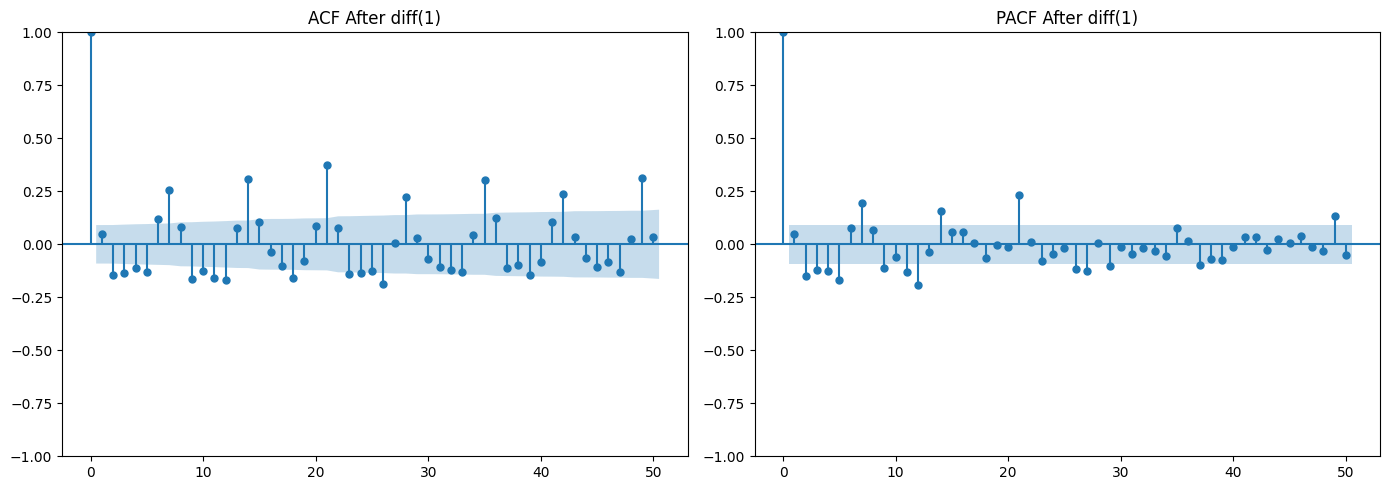

In [60]:

# First differencing (detrend)
series_diff = (
    train['visits_count']
    .diff(1)
    .dropna()
)

# Plot ACF/PACF
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(series_diff, lags=50, ax=axes[0])
plot_pacf(series_diff, lags=50, ax=axes[1])

axes[0].set_title('ACF After diff(1)')
axes[1].set_title('PACF After diff(1)')

plt.tight_layout()
plt.show()

In [61]:
p=0
d=1
q=0

In [62]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_arima = SARIMAX(train.visits_count, order=(p, d, q))
model_arima = model_arima.fit(disp=False)

forecast = model_arima.forecast(steps=len(test))

In [63]:
def plot(train, test, forecast):

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        x=train.index,
        y=train['visits_count'],
        label='Train'
    )

    sns.lineplot(
        x=test.index,
        y=test['visits_count'],
        label='Test'
    )

    sns.lineplot(
        x=test.index,
        y=forecast,
        label='Forecast'
    )

    plt.title('Train vs Test vs Forecast')
    plt.xlabel('Date')
    plt.ylabel('Visits Count')

    plt.show()

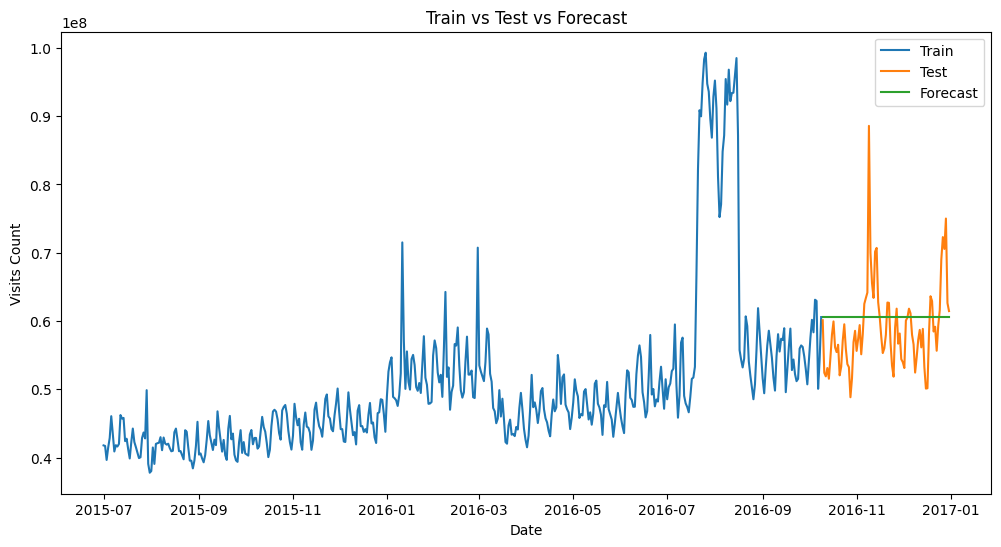

In [64]:
plot(train, test, forecast)

In [65]:
from sklearn.metrics import mean_absolute_percentage_error
def mape(test, forecast):

    error = mean_absolute_percentage_error(
        test['visits_count'],
        forecast
    )

    print('MAPE:', error)
    print('MAPE %:', error * 100)

In [66]:
mape(test, forecast)

MAPE: 0.08432370859668956
MAPE %: 8.432370859668955


#SARIMA

In [67]:
adf_test(train.visits_count.diff(7).dropna())

Augmented Dickey-Fuller Test

H0: Series is non-stationary
H1: Series is stationary

ADF Statistic: -3.7525721310374203
p-value: 0.0034315949313011183
No. of Lags Used: 14
Number of Observations Used: 445

Critical Values:
1%: -3.4451307246616514
5%: -2.86805689169311
10%: -2.570241263729327

Conclusion:
Reject H0
Series is stationary


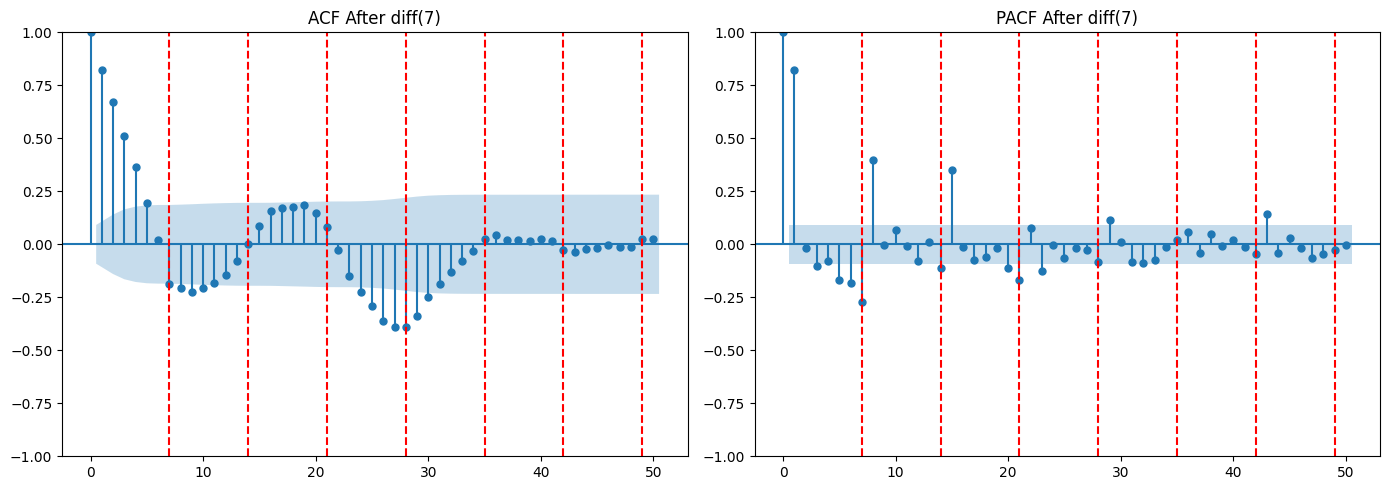

In [68]:
# deseason
series_diff = (
    train['visits_count']
    .diff(7)
    .dropna()
)

# Plot ACF/PACF
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(series_diff, lags=50, ax=axes[0])
plot_pacf(series_diff, lags=50, ax=axes[1])

seasonal_lags = [7, 14, 21, 28, 35, 42, 49]
for lag in seasonal_lags:
    axes[0].axvline(x=lag, color='r', linestyle='--')
    axes[1].axvline(x=lag, color='r', linestyle='--')

axes[0].set_title('ACF After diff(7)')
axes[1].set_title('PACF After diff(7)')

plt.tight_layout()
plt.show()

In [69]:
P = 3
D = 1
Q = 1
m = 7

In [70]:
model_sarima = SARIMAX(
    train['visits_count'],
    order=(p, d, q),
    seasonal_order=(P, D, Q, m)
)

model_sarima = model_sarima.fit(disp=False)
forecast = model_sarima.forecast(steps=len(test))

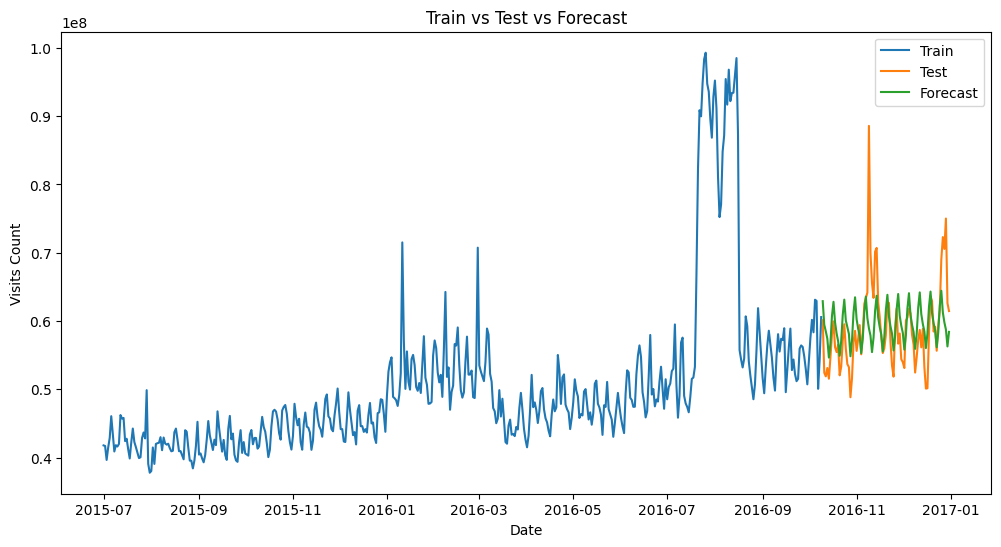

In [71]:
plot(train, test, forecast)

In [72]:
mape(test, forecast)

MAPE: 0.06622264677687345
MAPE %: 6.622264677687345


#SARIMAX

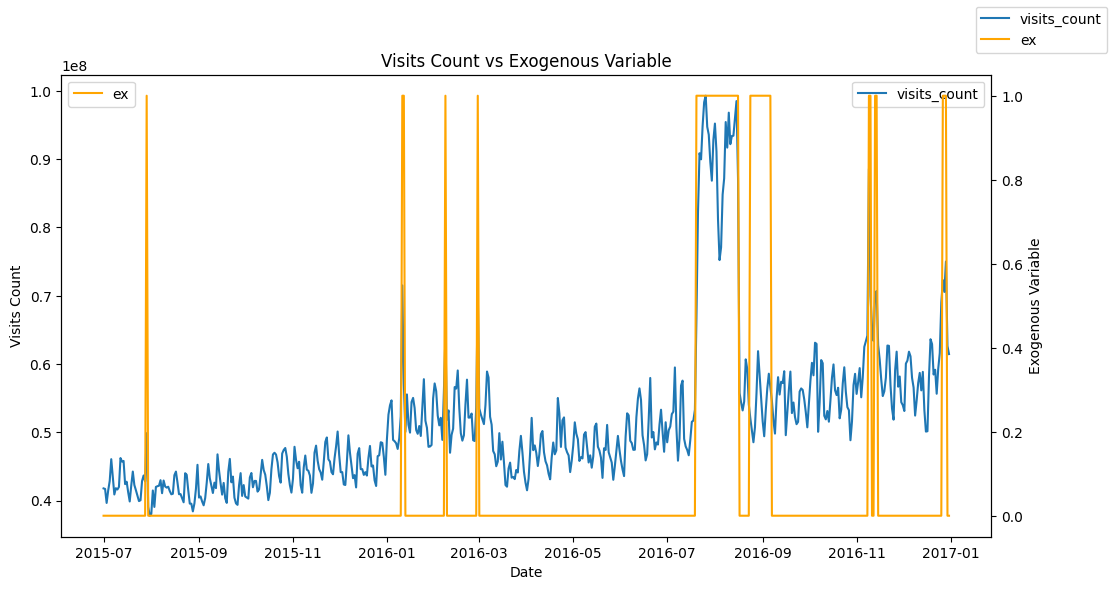

In [74]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(
    x=df_en.index,
    y=df_en['visits_count'],
    ax=ax1,
    label='visits_count'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Visits Count')

ax2 = ax1.twinx()

sns.lineplot(
    x=df_en.index,
    y=df_en['ex'],
    ax=ax2,
    label='ex',
    color='orange'
)

ax2.set_ylabel('Exogenous Variable')

plt.title('Visits Count vs Exogenous Variable')

fig.legend(loc='upper right')

plt.show()

In [75]:
model_sarimax = SARIMAX(
    train['visits_count'],
    exog=train[['ex']],
    order=(p, d, q),
    seasonal_order=(P, D, Q, m)
)

model_sarimax = model_sarimax.fit(disp=False)

In [76]:
forecast = model_sarimax.forecast(
    steps=len(test),
    exog=test[['ex']]
)

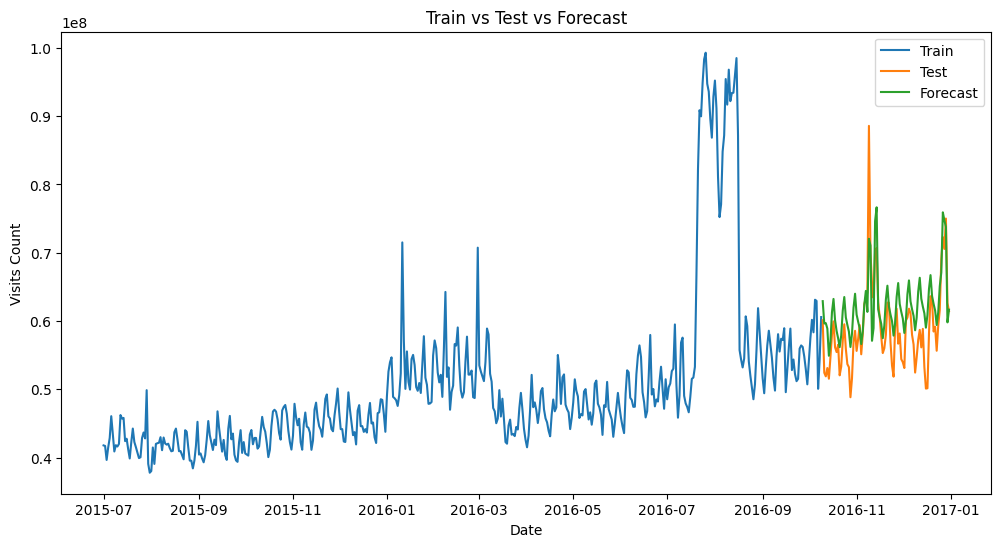

In [77]:
plot(train, test, forecast)

In [78]:
mape(test, forecast)

MAPE: 0.07217349810474427
MAPE %: 7.217349810474428


In [79]:
df_en['weekday'] = df_en.index.day_name()

In [80]:
df_en

,visits_count,ex,weekday
2015-07-01,41794296.0,0,Wednesday
2015-07-02,41716019.0,0,Thursday
2015-07-03,39667707.0,0,Friday
2015-07-04,41471104.0,0,Saturday
2015-07-05,42884745.0,0,Sunday
...,...,...,...
2016-12-27,72293618.0,1,Tuesday
2016-12-28,70559850.0,1,Wednesday
2016-12-29,75010915.0,1,Thursday
2016-12-30,62638944.0,0,Friday


In [81]:
weekend_days = {"Friday", "Saturday", "Sunday"}

df_en["is_weekend"] = df_en["weekday"].isin(weekend_days).astype(int)
df_en["is_weekday"] = (1 - df_en["is_weekend"]).astype(int)

In [82]:
df_en.drop(columns=['weekday'], inplace=True)
df_en

,visits_count,ex,is_weekend,is_weekday
2015-07-01,41794296.0,0,0,1
2015-07-02,41716019.0,0,0,1
2015-07-03,39667707.0,0,1,0
2015-07-04,41471104.0,0,1,0
2015-07-05,42884745.0,0,1,0
...,...,...,...,...
2016-12-27,72293618.0,1,0,1
2016-12-28,70559850.0,1,0,1
2016-12-29,75010915.0,1,0,1
2016-12-30,62638944.0,0,1,0


In [83]:
split_idx = int(len(df_en) * 0.85)

train = df_en.iloc[:split_idx]
test = df_en.iloc[split_idx:]

print(train.shape)
print(test.shape)

(467, 4)
(83, 4)


In [84]:
exog_cols = ["ex", "is_weekend", "is_weekday"]

In [85]:
model_sarimax = SARIMAX(
    train['visits_count'],
    exog=train[exog_cols],
    order=(p, d, q),
    seasonal_order=(P, D, Q, m)
)

model_sarimax = model_sarimax.fit(disp=False)

In [86]:
forecast = model_sarimax.forecast(
    steps=len(test),
    exog=test[exog_cols]
)

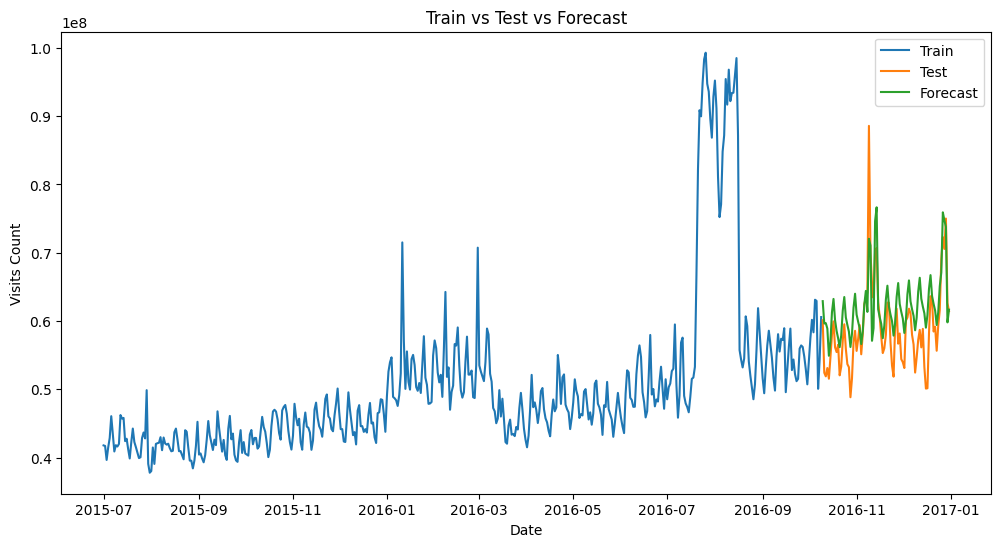

In [87]:
plot(train, test, forecast)

In [88]:
mape(test, forecast)

MAPE: 0.07217349782032027
MAPE %: 7.217349782032027


#Facebook Prophet

In [89]:
df_prophet = df_en.reset_index().rename(columns={
    'index': 'ds',
    'visits_count': 'y'
})
df_prophet

,ds,y,ex,is_weekend,is_weekday
0,2015-07-01,41794296.0,0,0,1
1,2015-07-02,41716019.0,0,0,1
2,2015-07-03,39667707.0,0,1,0
3,2015-07-04,41471104.0,0,1,0
4,2015-07-05,42884745.0,0,1,0
...,...,...,...,...,...
545,2016-12-27,72293618.0,1,0,1
546,2016-12-28,70559850.0,1,0,1
547,2016-12-29,75010915.0,1,0,1
548,2016-12-30,62638944.0,0,1,0


In [90]:
split_idx = int(len(df_en) * 0.85)

train = df_prophet.iloc[:split_idx]
test = df_prophet.iloc[split_idx:]

print(train.shape)
print(test.shape)

(467, 5)
(83, 5)


In [91]:
from prophet import Prophet

In [92]:
# changepoint between 0 and 1
# seasonality_prior_scale - 0 to 20
# holidays_prior_scale - 0 to 20
m = Prophet(changepoint_prior_scale=0.8, seasonality_prior_scale=5,holidays_prior_scale=5,yearly_seasonality=False,
    weekly_seasonality=True, daily_seasonality=False)

# add regressors
for col in exog_cols:
    m.add_regressor(col)

m.add_seasonality(
    name='weekly',
    period=7,
    fourier_order=2
)

m.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=2
)

# fit
m.fit(train)

In [93]:
future = test[['ds'] + exog_cols]
forecast = m.predict(future)

In [94]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,ex,...,monthly,monthly_lower,monthly_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-10-10,5.118190e+07,4.864612e+07,6.351244e+07,5.118190e+07,5.118190e+07,5.225750e+06,5.225750e+06,5.225750e+06,0.000000e+00,...,1.020767e+06,1.020767e+06,1.020767e+06,2.826894e+06,2.826894e+06,2.826894e+06,0.0,0.0,0.0,5.640765e+07
1,2016-10-11,5.113443e+07,4.620492e+07,6.150543e+07,5.113443e+07,5.113443e+07,2.640729e+06,2.640729e+06,2.640729e+06,0.000000e+00,...,9.560552e+05,9.560552e+05,9.560552e+05,3.065848e+05,3.065848e+05,3.065848e+05,0.0,0.0,0.0,5.377516e+07
2,2016-10-12,5.108696e+07,4.460577e+07,6.005324e+07,5.108696e+07,5.108696e+07,1.378253e+06,1.378253e+06,1.378253e+06,0.000000e+00,...,8.271633e+05,8.271633e+05,8.271633e+05,-8.269992e+05,-8.269992e+05,-8.269992e+05,0.0,0.0,0.0,5.246521e+07
3,2016-10-13,5.103949e+07,4.394806e+07,5.858388e+07,5.103949e+07,5.103949e+07,5.232867e+05,5.232867e+05,5.232867e+05,0.000000e+00,...,6.661848e+05,6.661848e+05,6.661848e+05,-1.520987e+06,-1.520987e+06,-1.520987e+06,0.0,0.0,0.0,5.156278e+07
4,2016-10-14,5.099202e+07,4.285821e+07,5.783013e+07,5.097181e+07,5.100888e+07,-8.600961e+05,-8.600961e+05,-8.600961e+05,0.000000e+00,...,5.060854e+05,5.060854e+05,5.060854e+05,-2.007003e+06,-2.007003e+06,-2.007003e+06,0.0,0.0,0.0,5.013192e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,2016-12-27,4.747923e+07,5.924195e+07,8.237905e+07,3.906434e+07,5.667999e+07,2.285727e+07,2.285727e+07,2.285727e+07,2.197392e+07,...,-8.013303e+05,-8.013303e+05,-8.013303e+05,3.065848e+05,3.065848e+05,3.065848e+05,0.0,0.0,0.0,7.033650e+07
79,2016-12-28,4.743176e+07,5.781501e+07,8.006040e+07,3.882635e+07,5.679321e+07,2.145277e+07,2.145277e+07,2.145277e+07,2.197392e+07,...,-1.072248e+06,-1.072248e+06,-1.072248e+06,-8.269992e+05,-8.269992e+05,-8.269992e+05,0.0,0.0,0.0,6.888453e+07
80,2016-12-29,4.738429e+07,5.635814e+07,8.005044e+07,3.855347e+07,5.682231e+07,2.055601e+07,2.055601e+07,2.055601e+07,2.197392e+07,...,-1.275017e+06,-1.275017e+06,-1.275017e+06,-1.520987e+06,-1.520987e+06,-1.520987e+06,0.0,0.0,0.0,6.794030e+07
81,2016-12-30,4.733682e+07,3.285554e+07,5.783461e+07,3.836781e+07,5.684037e+07,-2.744354e+06,-2.744354e+06,-2.744354e+06,0.000000e+00,...,-1.378172e+06,-1.378172e+06,-1.378172e+06,-2.007003e+06,-2.007003e+06,-2.007003e+06,0.0,0.0,0.0,4.459247e+07


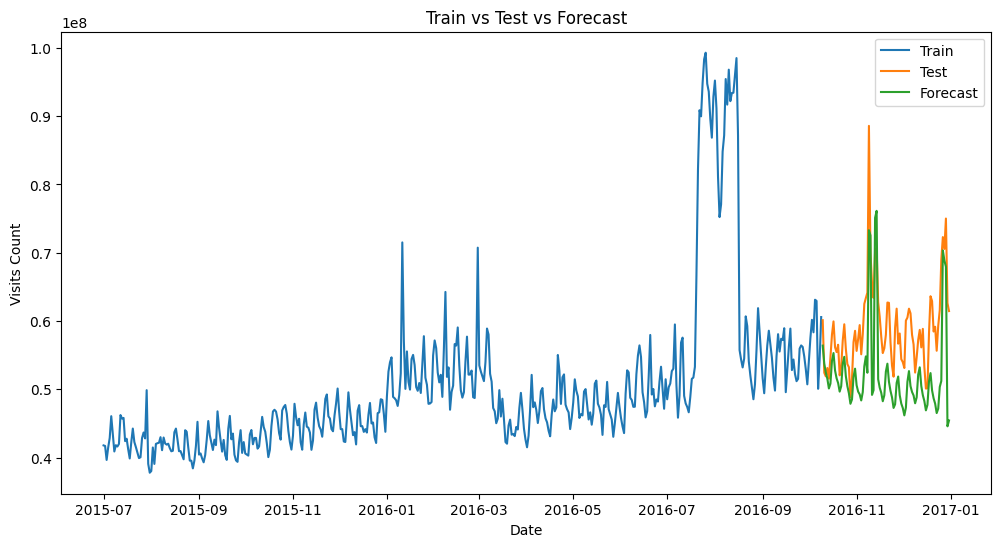

In [95]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=train.ds,
    y=train['y'],
    label='Train'
)

sns.lineplot(
    x=test.ds,
    y=test['y'],
    label='Test'
)

sns.lineplot(
    x=forecast.ds,
    y=forecast.yhat,
    label='Forecast'
)

plt.title('Train vs Test vs Forecast')
plt.xlabel('Date')
plt.ylabel('Visits Count')

plt.show()

In [96]:
mean_absolute_percentage_error(test.y, forecast.yhat) * 100

11.892521760746869

##Tunning Prophet

In [97]:
import itertools


# TRAIN / VALIDATION SPLIT
# last 30 rows for validation
train_df = train.iloc[:-30].copy()
val_df = train.iloc[-30:].copy()


param_grid = {

    'changepoint_prior_scale': [
        0.01,
        0.05,
        0.1
    ],

    'seasonality_prior_scale': [
        0.1,
        1,
        5
    ],

    'seasonality_mode': [
        'additive',
        'multiplicative'
    ],

    'n_changepoints': [
        10,
        25
    ],

    'weekly_fourier_order': [
        2,
        3
    ]
}


# ALL COMBINATIONS

all_params = list(
    itertools.product(
        param_grid['changepoint_prior_scale'],
        param_grid['seasonality_prior_scale'],
        param_grid['seasonality_mode'],
        param_grid['n_changepoints'],
        param_grid['weekly_fourier_order']
    )
)

print(f"Total Models: {len(all_params)}")

results = []


# GRID SEARCH


for i, params in enumerate(all_params):

    (
        cps,
        sps,
        smode,
        ncp,
        wf
    ) = params

    try:


        # MODEL

        m = Prophet(

            changepoint_prior_scale=cps,
            seasonality_prior_scale=sps,
            seasonality_mode=smode,

            n_changepoints=ncp,

            weekly_seasonality=False,
            yearly_seasonality=False,
            daily_seasonality=False,

            # faster
            mcmc_samples=0
        )

        # EXOGENOUS VARIABLES

        for col in exog_cols:
            m.add_regressor(col)

        # SEASONALITY

        m.add_seasonality(
            name='weekly',
            period=7,
            fourier_order=wf
        )


        m.fit(train_df)
        future = val_df[['ds'] + exog_cols]
        forecast = m.predict(future)

        mape = mean_absolute_percentage_error(
            val_df['y'],
            forecast['yhat']
        )

        results.append({

            'changepoint_prior_scale': cps,
            'seasonality_prior_scale': sps,
            'seasonality_mode': smode,
            'n_changepoints': ncp,
            'weekly_fourier_order': wf,
            'mape': mape
        })

    except Exception as e:
        print("Error:", e)

# RESULTS

results_df = pd.DataFrame(results)

results_df = results_df.sort_values('mape')

print("\nTop Models:\n")

print(results_df.head(10))

# BEST PARAMS
best_params = results_df.iloc[0]

print("\nBest Parameters:\n")

print(best_params)

Total Models: 72


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted



Top Models:

    changepoint_prior_scale  seasonality_prior_scale seasonality_mode  \
12                     0.01                      1.0   multiplicative   
14                     0.01                      1.0   multiplicative   
20                     0.01                      5.0   multiplicative   
6                      0.01                      0.1   multiplicative   
15                     0.01                      1.0   multiplicative   
22                     0.01                      5.0   multiplicative   
18                     0.01                      5.0         additive   
10                     0.01                      1.0         additive   
11                     0.01                      1.0         additive   
2                      0.01                      0.1         additive   

    n_changepoints  weekly_fourier_order      mape  
12              10                     2  0.042158  
14              25                     2  0.042379  
20              10     

In [98]:
# changepoint between 0 and 1
# seasonality_prior_scale - 0 to 20
# holidays_prior_scale - 0 to 20
m = Prophet(changepoint_prior_scale=0.01, seasonality_prior_scale=1,seasonality_mode='multiplicative',yearly_seasonality=False,n_changepoints=10,
    weekly_seasonality=False, daily_seasonality=False)

# add regressors
for col in exog_cols:
    m.add_regressor(col)

m.add_seasonality(
    name='weekly',
    period=7,
    fourier_order=2
)

# fit
m.fit(train)

In [99]:
future = test[['ds'] + exog_cols]
forecast = m.predict(future)

In [100]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,ex,ex_lower,ex_upper,extra_regressors_multiplicative,...,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2016-10-10,5.536893e+07,5.030767e+07,6.603938e+07,5.536893e+07,5.536893e+07,0.00000,0.00000,0.00000,-0.009604,...,0.050660,0.050660,0.050660,0.060263,0.060263,0.060263,0.0,0.0,0.0,5.817391e+07
1,2016-10-11,5.539789e+07,4.787375e+07,6.300354e+07,5.539789e+07,5.539789e+07,0.00000,0.00000,0.00000,-0.009604,...,0.002865,0.002865,0.002865,0.012469,0.012469,0.012469,0.0,0.0,0.0,5.555663e+07
2,2016-10-12,5.542684e+07,4.638441e+07,6.159911e+07,5.542684e+07,5.542684e+07,0.00000,0.00000,0.00000,-0.009604,...,-0.024510,-0.024510,-0.024510,-0.014906,-0.014906,-0.014906,0.0,0.0,0.0,5.406834e+07
3,2016-10-13,5.545580e+07,4.551465e+07,6.153003e+07,5.545580e+07,5.545580e+07,0.00000,0.00000,0.00000,-0.009604,...,-0.034934,-0.034934,-0.034934,-0.025330,-0.025330,-0.025330,0.0,0.0,0.0,5.351852e+07
4,2016-10-14,5.548475e+07,4.393665e+07,5.945682e+07,5.548475e+07,5.548475e+07,0.00000,0.00000,0.00000,-0.017663,...,-0.066700,-0.066700,-0.066700,-0.049037,-0.049037,-0.049037,0.0,0.0,0.0,5.178391e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,2016-12-27,5.762739e+07,7.593909e+07,9.123530e+07,5.761699e+07,5.763824e+07,0.45079,0.45079,0.45079,0.441186,...,0.453655,0.453655,0.453655,0.012469,0.012469,0.012469,0.0,0.0,0.0,8.377034e+07
79,2016-12-28,5.765634e+07,7.443656e+07,9.033205e+07,5.764572e+07,5.766738e+07,0.45079,0.45079,0.45079,0.441186,...,0.426280,0.426280,0.426280,-0.014906,-0.014906,-0.014906,0.0,0.0,0.0,8.223407e+07
80,2016-12-29,5.768530e+07,7.416259e+07,8.926624e+07,5.767444e+07,5.769643e+07,0.45079,0.45079,0.45079,0.441186,...,0.415856,0.415856,0.415856,-0.025330,-0.025330,-0.025330,0.0,0.0,0.0,8.167407e+07
81,2016-12-30,5.771425e+07,4.621442e+07,6.176954e+07,5.770319e+07,5.772555e+07,0.00000,0.00000,0.00000,-0.017663,...,-0.066700,-0.066700,-0.066700,-0.049037,-0.049037,-0.049037,0.0,0.0,0.0,5.386470e+07


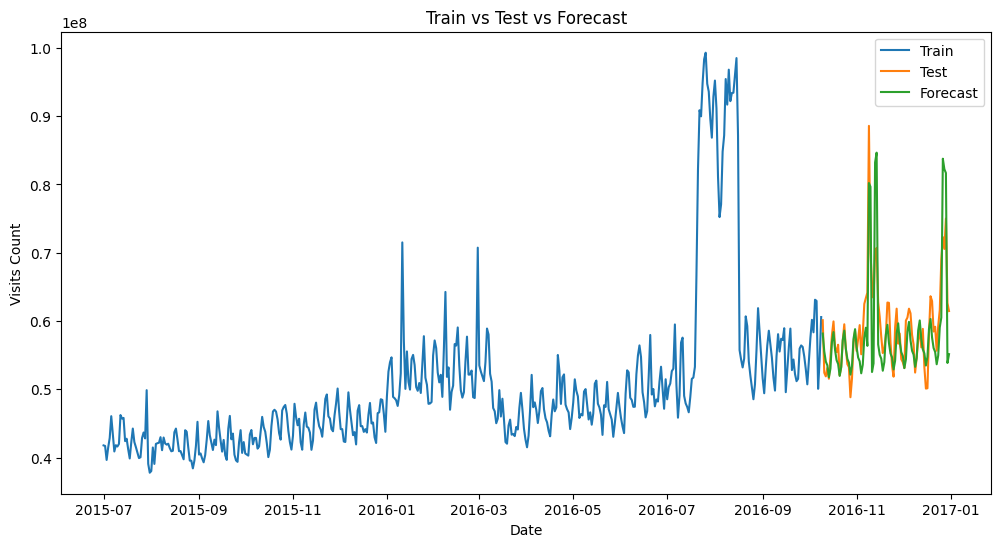

In [101]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=train.ds,
    y=train['y'],
    label='Train'
)

sns.lineplot(
    x=test.ds,
    y=test['y'],
    label='Test'
)

sns.lineplot(
    x=forecast.ds,
    y=forecast.yhat,
    label='Forecast'
)

plt.title('Train vs Test vs Forecast')
plt.xlabel('Date')
plt.ylabel('Visits Count')

plt.show()

In [102]:
mean_absolute_percentage_error(test.y, forecast.yhat) * 100

5.511748126559664

This is lowest mape % we got for `en` language pages.

# Production-Level Multi-Series Forecasting Pipeline

## Objectives

This pipeline:

* Supports multiple language series
* Automatically detects:

  * trend differencing (`d`)
  * seasonality (`m`)
  * ARIMA orders (`p,q`)
  * seasonal orders (`P,Q`)
* Trains:

  * ARIMA
  * SARIMA
  * SARIMAX
  * Prophet
* Tunes Prophet automatically
* Compares models using MAPE
* Handles:

  * overlapping seasonal/non-seasonal lags
  * exogenous regressors
  * missing values
  * weak/no seasonality
  * unstable parameter combinations
  * custom exogeneous variable for each language
* Produces:

  * ACF/PACF plots
  * Forecast plots
  * final leaderboard


##1. Imports

In [103]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import logging
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_percentage_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf

from prophet import Prophet

##2. Logging

In [104]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger(__name__)

##3. Utility Functions

###3.1 MAPE

In [105]:
def safe_mape(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask]) /
                y_true[mask]
            )
        ) * 100
    )

###3.2 Stationarity Detection

In [106]:
def find_d(series, max_d=2):
    for d in range(max_d + 1):
        if d == 0:
            temp = series.copy()
        else:
            temp = series.diff(d).dropna()

        pvalue = adfuller(temp)[1]

        if pvalue < 0.05:
            return d

    return 1

###3.3 Seasonality Detection

In [107]:
def find_seasonal_period(series, max_lag=30):
    acf_vals = acf(series, nlags=max_lag)
    threshold = 1.96 / np.sqrt(len(series))
    candidates = []

    for lag in range(2, max_lag + 1):
        if abs(acf_vals[lag]) > threshold:
            candidates.append(
                (lag, abs(acf_vals[lag]))
            )

    if len(candidates) == 0:
        return 0

    best = max(candidates, key=lambda x: x[1])[0]

    if best <= 3:
        return 0

    return best

###3.4 Extract p/q

In [108]:
# ============
# EXTRACT p/q
# ============

def extract_pq(
    series,
    seasonal_period,
    lang,
    d,
    max_lag=15
):

    # -----------------
    # ACF / PACF VALUES
    # ------------------

    acf_vals = acf(
        series,
        nlags=max_lag
    )

    pacf_vals = pacf(
        series,
        nlags=max_lag
    )

    threshold = (
        1.96 / np.sqrt(len(series))
    )

    # ----
    # PLOT
    # -----

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    plot_acf(
        series,
        lags=min(
            40,
            len(series)//2
        ),
        ax=axes[0]
    )

    plot_pacf(
        series,
        lags=min(
            40,
            len(series)//2
        ),
        ax=axes[1]
    )

    axes[0].set_title(
        f'{lang} - ACF After diff({d})'
    )

    axes[1].set_title(
        f'{lang} - PACF After diff({d})'
    )

    plt.tight_layout()
    plt.show()

    # ------------
    # p from PACF
    # ------------

    p = 0

    for lag in range(
        1,
        max_lag
    ):

        if seasonal_period > 1:
            if lag % seasonal_period == 0:
                continue

        if abs(pacf_vals[lag]) > threshold:
            p = lag
        else:
            break

    # -----------
    # q from ACF
    # ----------

    q = 0

    for lag in range(
        1,
        max_lag
    ):

        if seasonal_period > 1:
            if lag % seasonal_period == 0:
                continue

        if abs(acf_vals[lag]) > threshold:
            q = lag
        else:
            break

    # -----------
    # SAFETY CAPS
    # ------------

    p = min(p, 3)
    q = min(q, 3)

    print(f"\nDetected p = {p}")
    print(f"Detected q = {q}")

    return p, q

###3.5 Extract P/Q

In [109]:
# ============
# EXTRACT P/Q
# ===========

def extract_seasonal_pq(
    series,
    seasonal_period,
    lang,
    D
):

    # -----------------
    # ACF / PACF VALUES
    # -----------------

    acf_vals = acf(
        series,
        nlags=max(
            seasonal_period * 3,
            10
        )
    )

    pacf_vals = pacf(
        series,
        nlags=max(
            seasonal_period * 3,
            10
        )
    )

    threshold = (
        1.96 / np.sqrt(len(series))
    )

    # ----
    # PLOT
    # ----

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    plot_acf(
        series,
        lags=min(
            50,
            len(series)//2
        ),
        ax=axes[0]
    )

    plot_pacf(
        series,
        lags=min(
            50,
            len(series)//2
        ),
        ax=axes[1]
    )

    seasonal_lags = [
        seasonal_period,
        seasonal_period * 2,
        seasonal_period * 3,
        seasonal_period * 4
    ]

    for lag in seasonal_lags:
        axes[0].axvline(
            x=lag,
            color='r',
            linestyle='--'
        )

        axes[1].axvline(
            x=lag,
            color='r',
            linestyle='--'
        )

    axes[0].set_title(
        f'{lang} - Seasonal ACF'
    )

    axes[1].set_title(
        f'{lang} - Seasonal PACF'
    )

    plt.tight_layout()
    plt.show()

    # -----------
    # P from PACF
    # -----------

    P = 0

    for k in range(1, 4):
        lag = seasonal_period * k
        if lag >= len(pacf_vals):
            break

        if abs(pacf_vals[lag]) > threshold:
            P = k
        else:
            break

    # ----------
    # Q from ACF
    # -----------

    Q = 0

    for k in range(1, 4):
        lag = seasonal_period * k
        if lag >= len(acf_vals):
            break

        if abs(acf_vals[lag]) > threshold:
            Q = k
        else:
            break

    # ------------
    # SAFETY CAPS
    # ------------

    P = min(P, 2)
    Q = min(Q, 2)

    print(f"\nDetected P = {P}")
    print(f"Detected D = {D}")
    print(f"Detected Q = {Q}")
    print(f"Detected m = {seasonal_period}")

    return P, Q

##4. Plotting

In [110]:
def plot_forecast(train, test, forecast, title):

    plt.figure(figsize=(12, 5))

    sns.lineplot(
        x=train.index,
        y=train.values,
        label='Train'
    )

    sns.lineplot(
        x=test.index,
        y=test.values,
        label='Test'
    )

    sns.lineplot(
        x=test.index,
        y=forecast,
        label='Forecast'
    )

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Value')

    plt.show()

##5. Prophet Tuning

In [111]:
def tune_prophet(
    train_prophet,
    exog_cols,
    seasonal_period
):

    train_df = train_prophet.iloc[:-30].copy()
    val_df = train_prophet.iloc[-30:].copy()

    train_df = train_df.dropna()
    val_df = val_df.dropna()

    param_grid = {
        'changepoint_prior_scale': [
            0.01,
            0.05,
            0.1
        ],

        'seasonality_prior_scale': [
            0.1,
            1,
            5
        ],

        'seasonality_mode': [
            'additive',
            'multiplicative'
        ],

        'n_changepoints': [
            10,
            25
        ],

        'fourier_order': [
            2,
            3,
            5
        ]
    }

    all_params = list(
        itertools.product(
            param_grid['changepoint_prior_scale'],
            param_grid['seasonality_prior_scale'],
            param_grid['seasonality_mode'],
            param_grid['n_changepoints'],
            param_grid['fourier_order']
        )
    )

    results = []

    for params in all_params:

        (
            cps,
            sps,
            smode,
            ncp,
            fourier_order
        ) = params

        try:

            if smode == 'multiplicative':
                if (train_df['y'] <= 0).any():
                    continue

            model = Prophet(
                changepoint_prior_scale=cps,
                seasonality_prior_scale=sps,
                seasonality_mode=smode,
                n_changepoints=ncp,
                yearly_seasonality=False,
                weekly_seasonality=False,
                daily_seasonality=False,
                mcmc_samples=0
            )

            for col in exog_cols:
                model.add_regressor(col)

            if seasonal_period > 1:
                model.add_seasonality(
                    name='custom',
                    period=seasonal_period,
                    fourier_order=fourier_order
                )

            model.fit(train_df)

            future = val_df[['ds'] + list(exog_cols)]

            forecast = model.predict(future)

            mape = safe_mape(
                val_df['y'],
                forecast['yhat']
            )

            results.append({
                'params': params,
                'mape': mape
            })

        except Exception as e:
            logger.warning(e)

    if len(results) == 0:
        return {
            'changepoint_prior_scale': 0.05,
            'seasonality_prior_scale': 1,
            'seasonality_mode': 'additive',
            'n_changepoints': 10,
            'fourier_order': 3
        }

    best = min(results, key=lambda x: x['mape'])

    (
        cps,
        sps,
        smode,
        ncp,
        fourier_order
    ) = best['params']

    return {
        'changepoint_prior_scale': cps,
        'seasonality_prior_scale': sps,
        'seasonality_mode': smode,
        'n_changepoints': ncp,
        'fourier_order': fourier_order
    }

##6. Exogeneus Var setup

In [112]:
exog_train = train[['is_weekend']]
exog_test = test[['is_weekend']]

exog_train.index = train.ds
exog_test.index = test.ds

- COMMON EXOG FOR ALL LANGS
`exog_train`
`exog_test`

In [113]:
# EXTRA EXOG ONLY FOR SOME LANGS

extra_exog_train_dict = {
    'en' : ex[:split_idx]
}

extra_exog_test_dict = {
    'en' : ex[split_idx:]
}

##6. Main Forecasting Pipeline

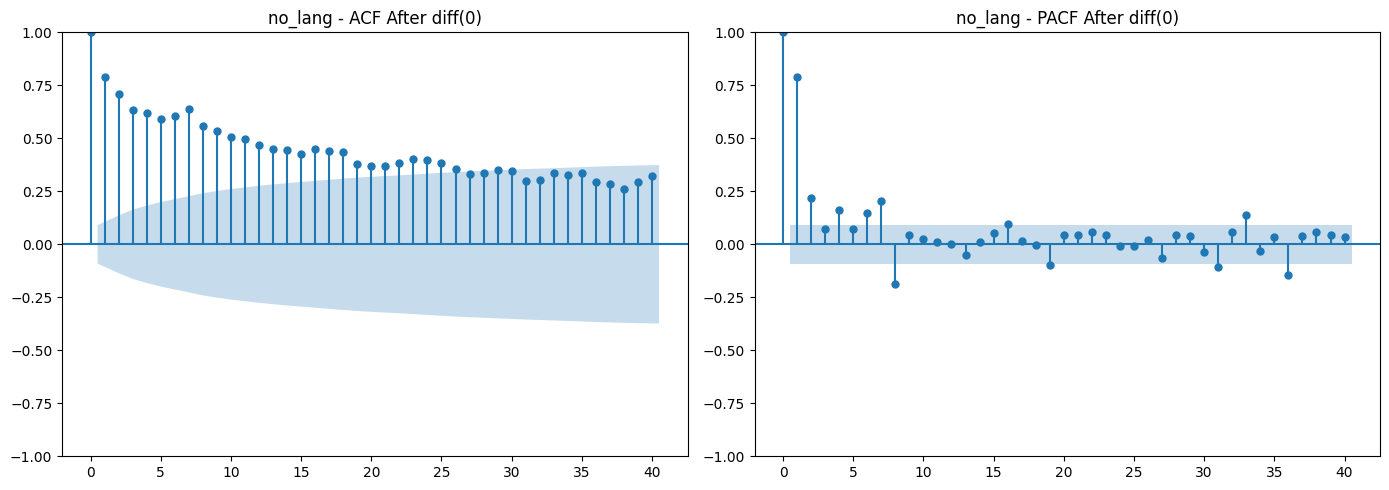


Detected p = 2
Detected q = 3


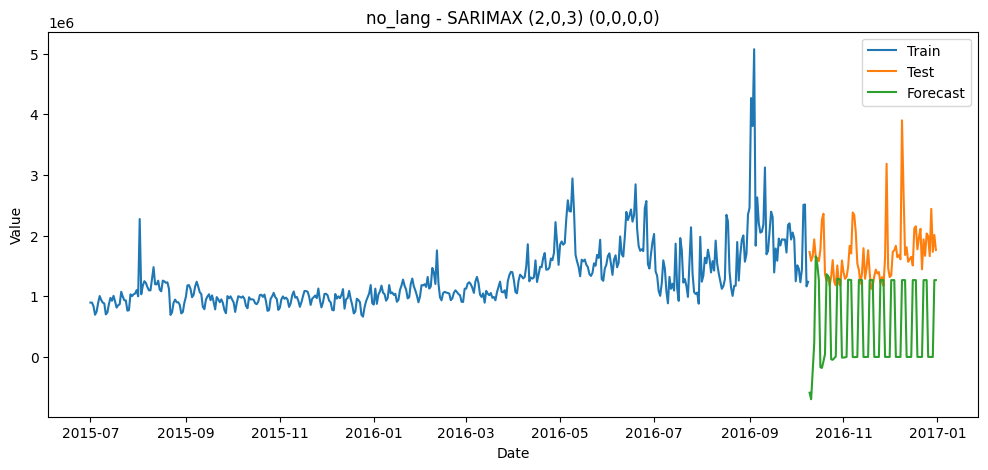

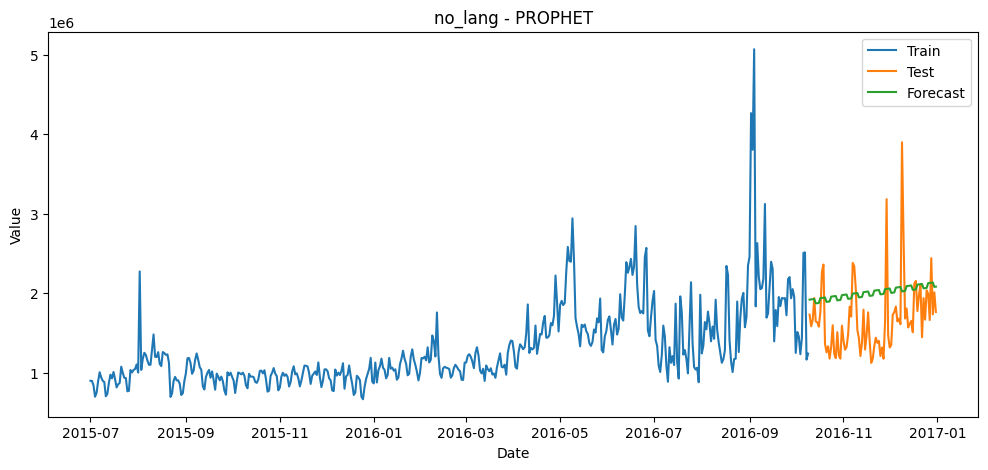

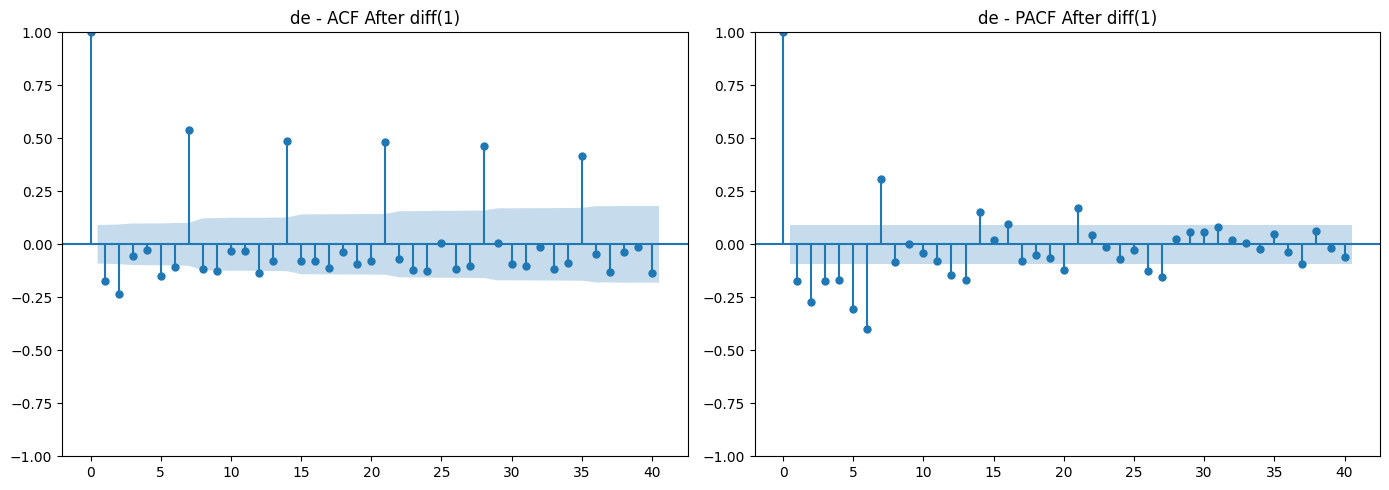


Detected p = 3
Detected q = 2


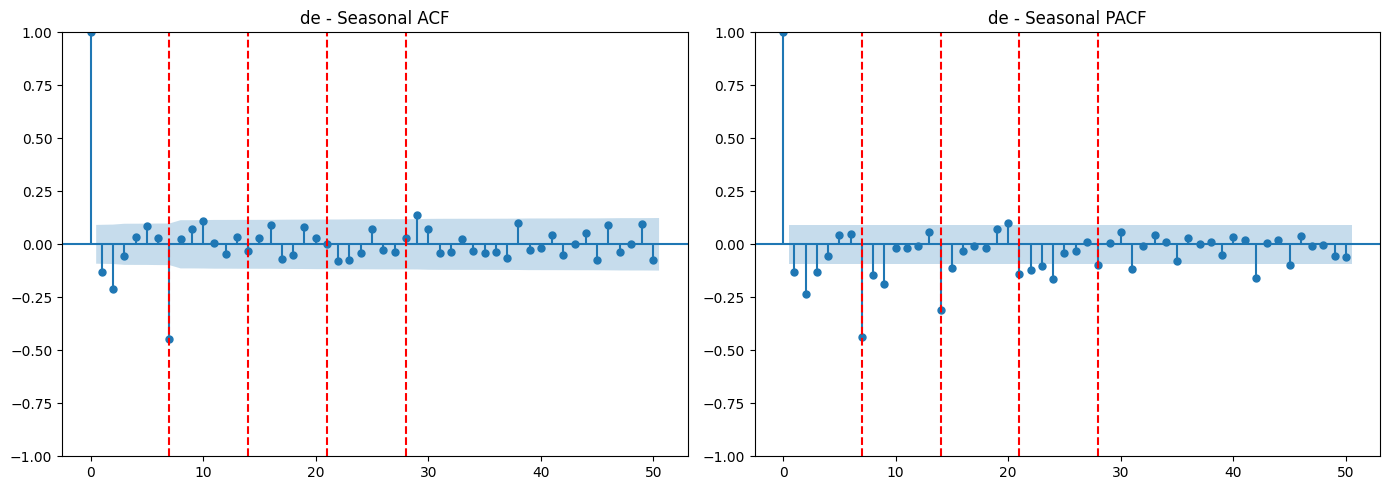


Detected P = 2
Detected D = 0
Detected Q = 1
Detected m = 7


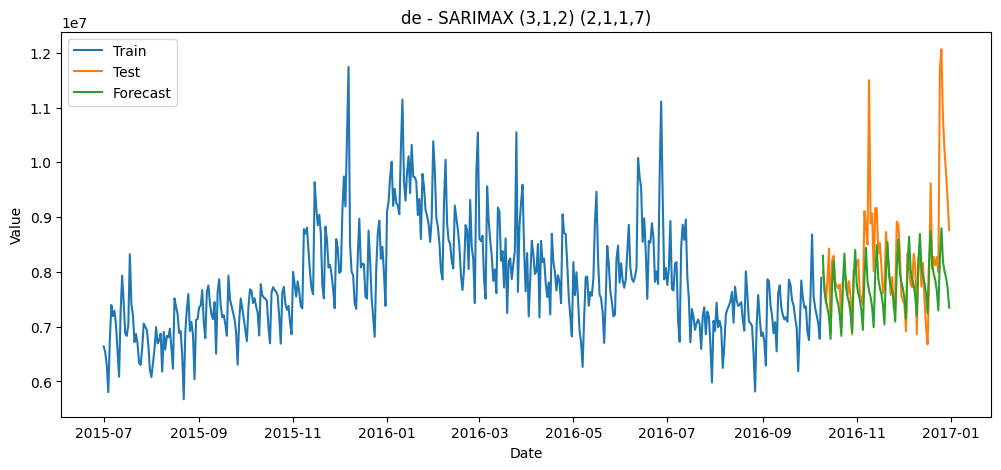

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


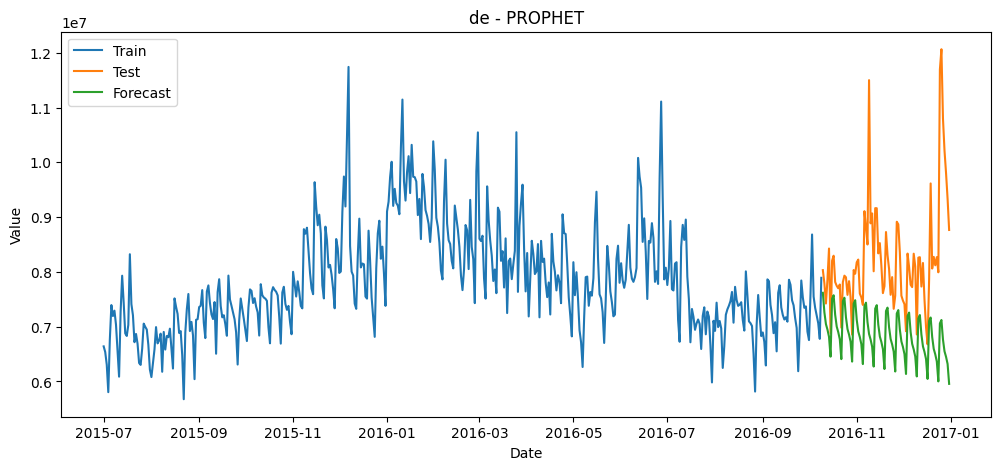

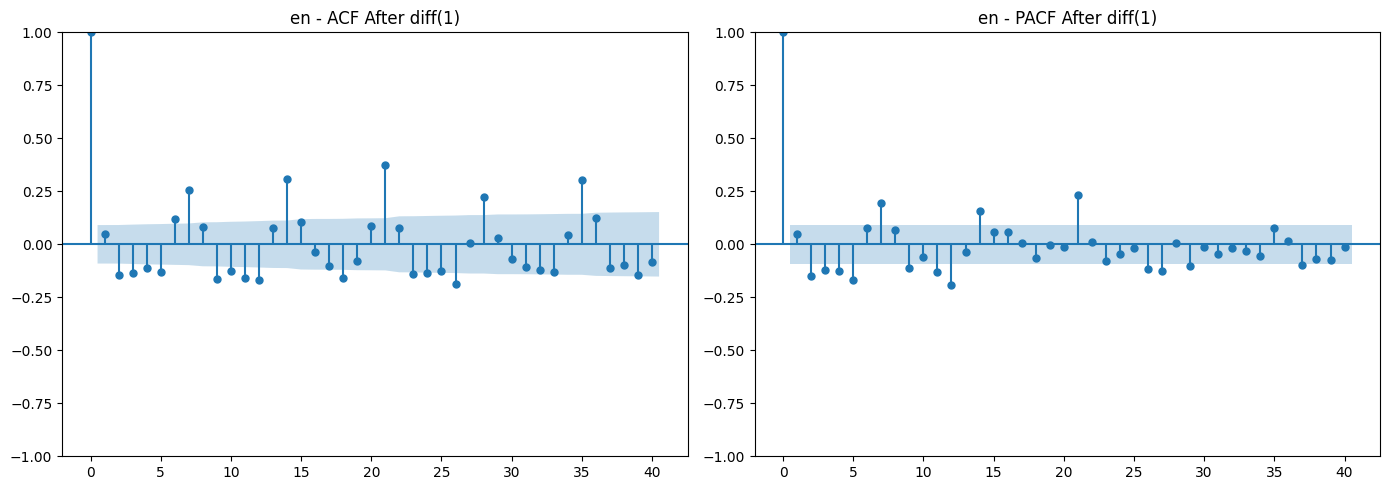


Detected p = 0
Detected q = 0


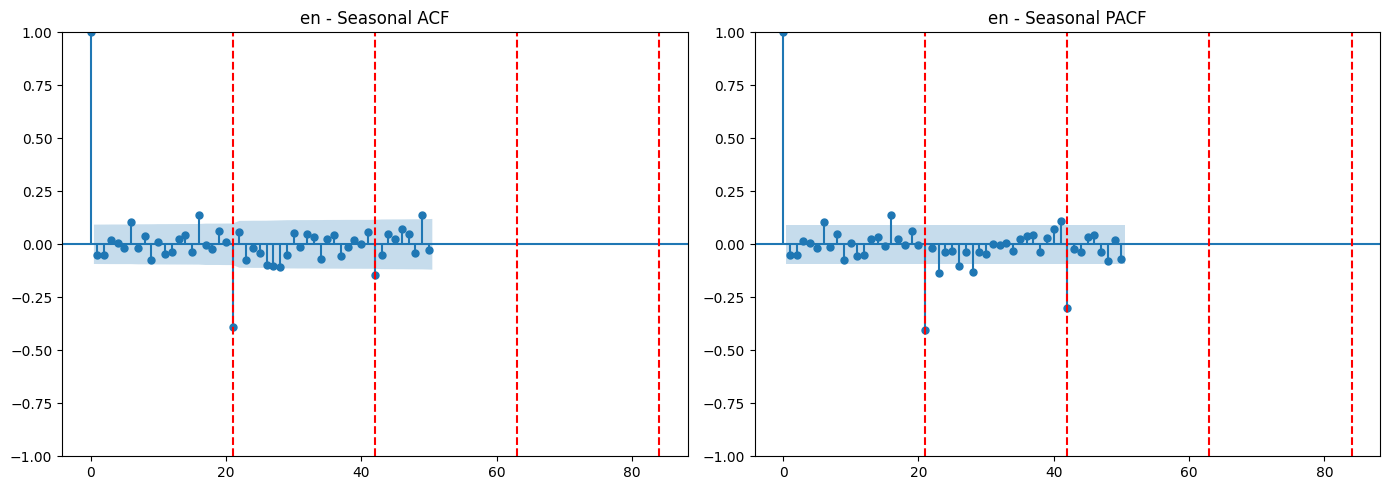


Detected P = 2
Detected D = 1
Detected Q = 2
Detected m = 21


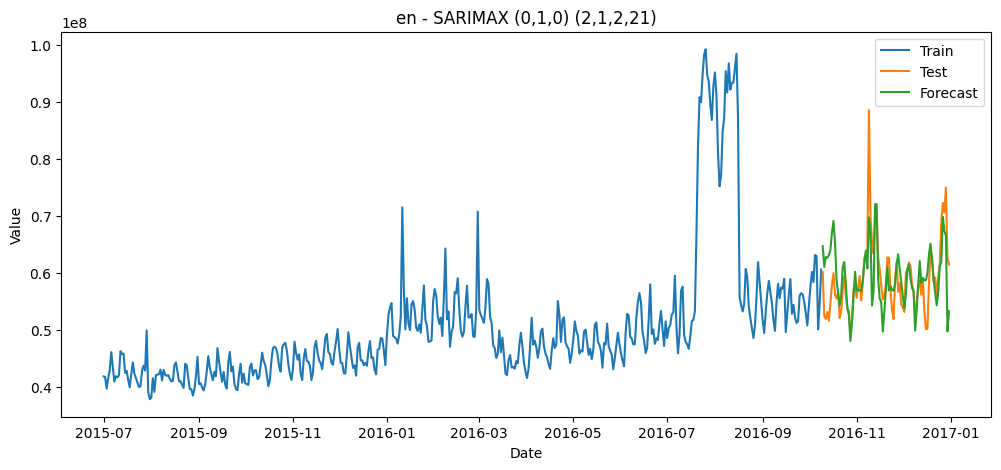

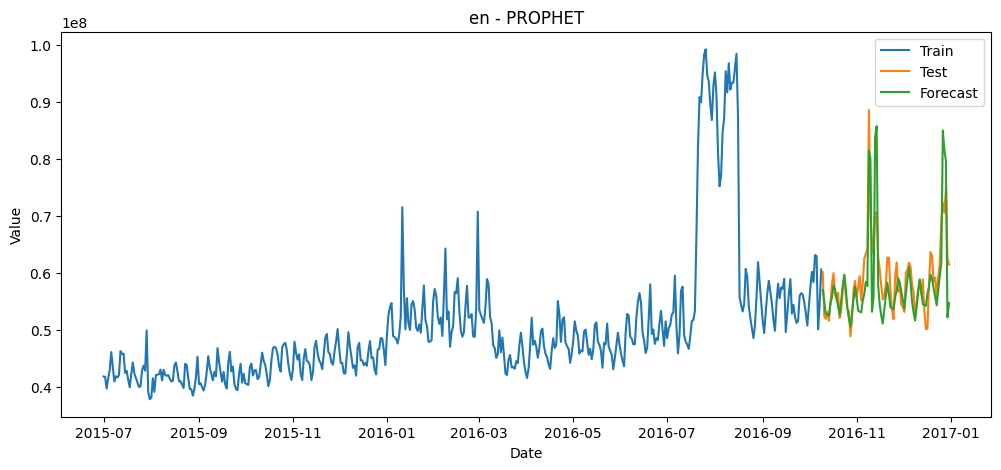

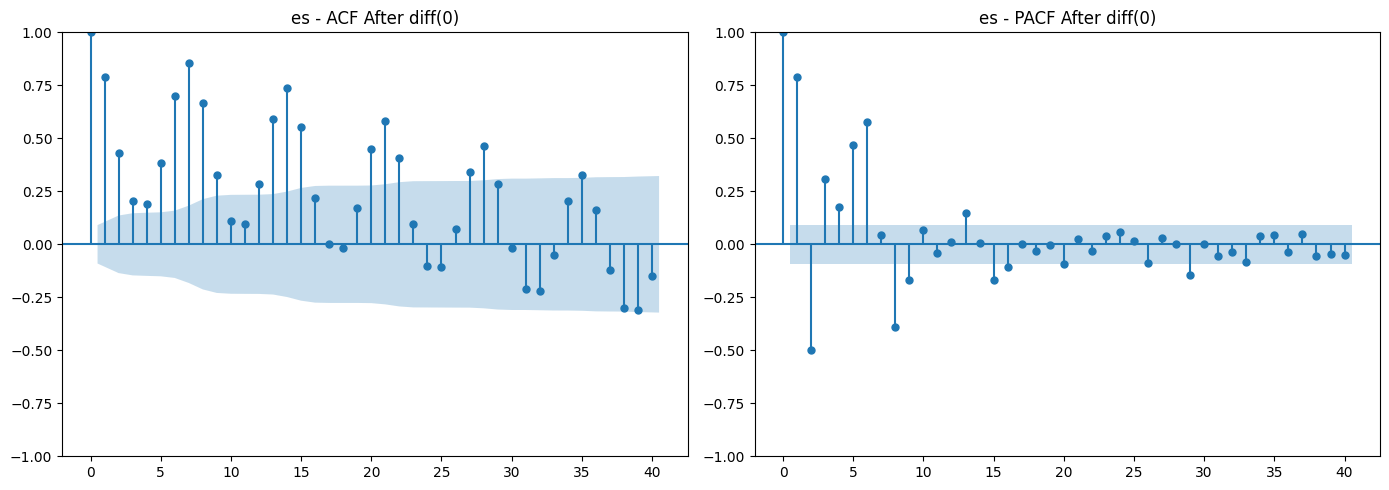


Detected p = 3
Detected q = 3


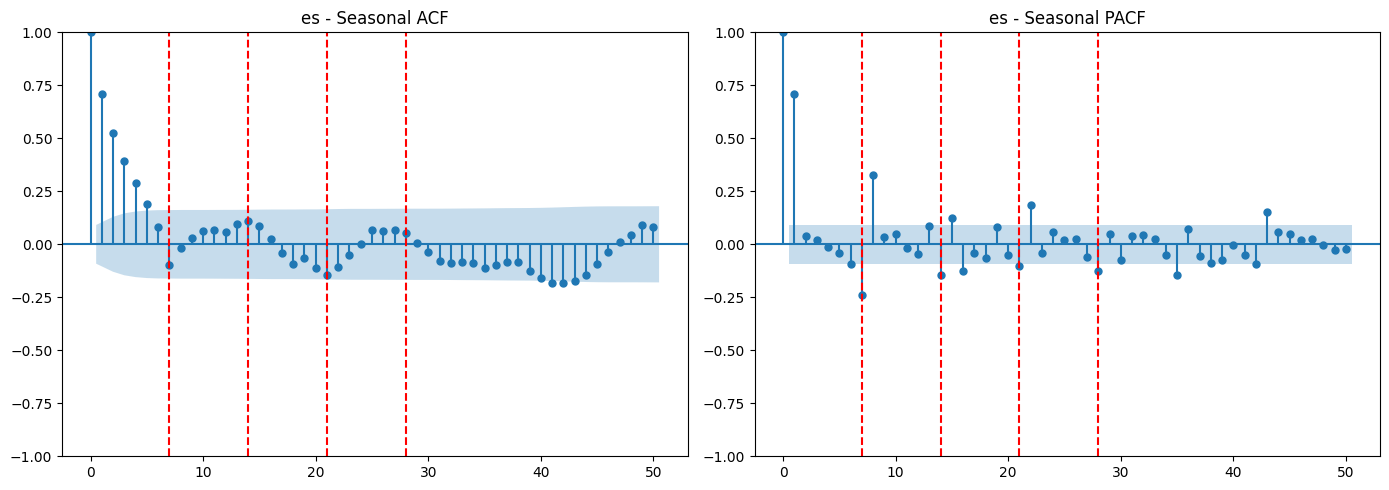


Detected P = 2
Detected D = 1
Detected Q = 2
Detected m = 7


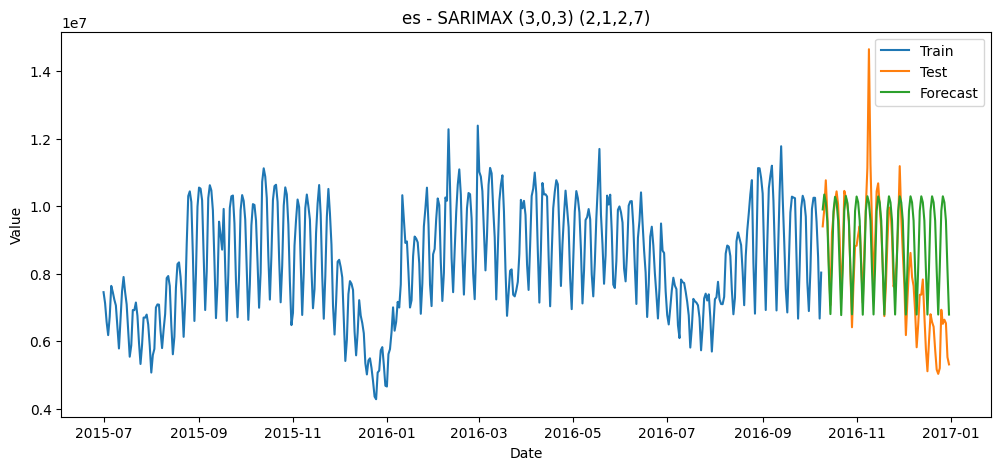

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


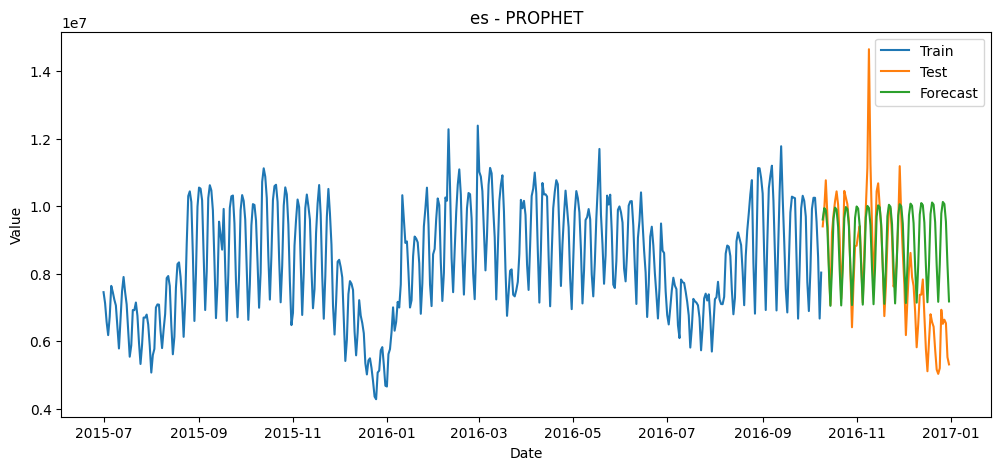

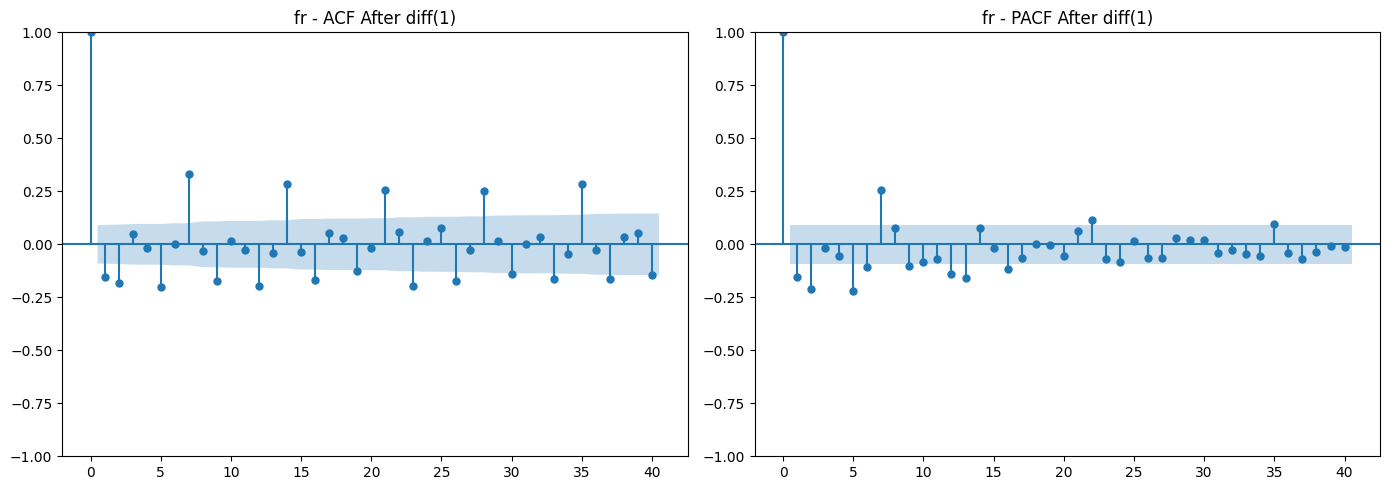


Detected p = 2
Detected q = 2


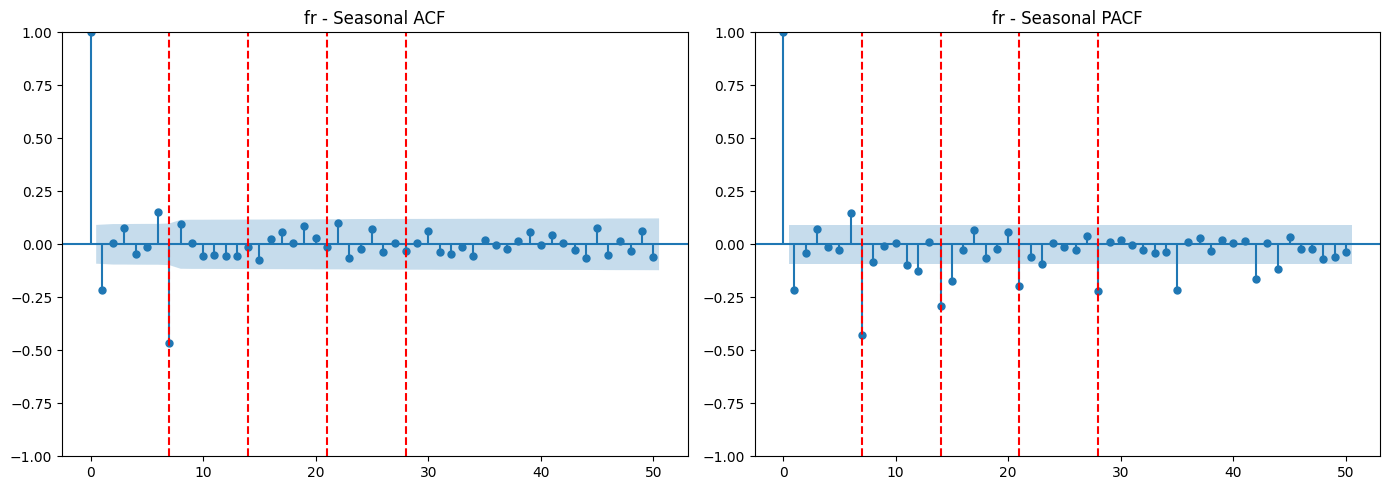


Detected P = 2
Detected D = 1
Detected Q = 1
Detected m = 7


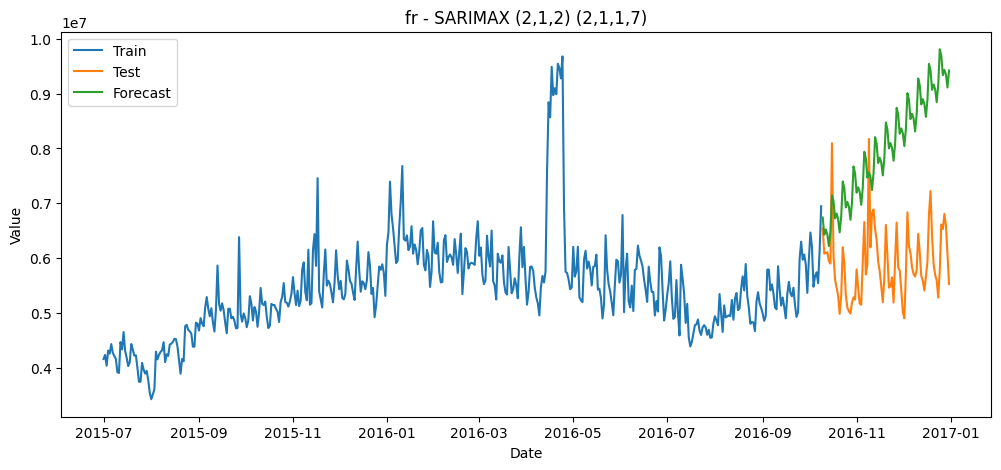

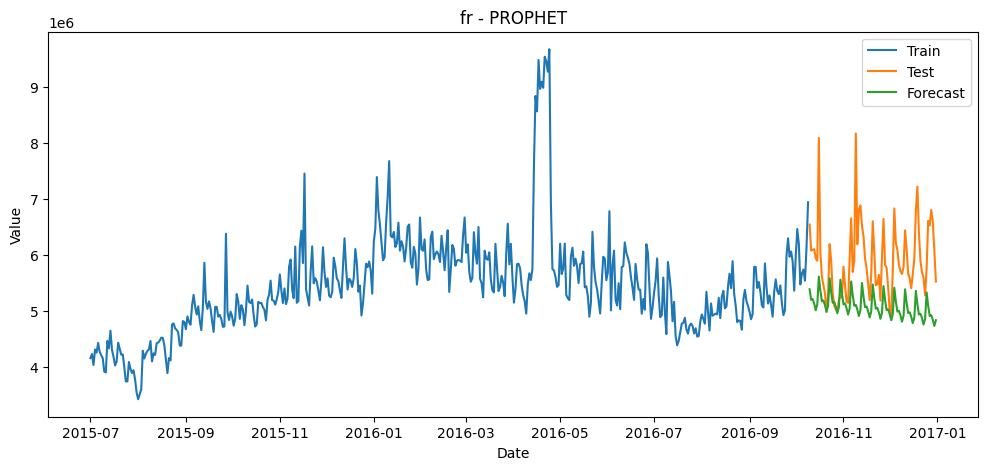

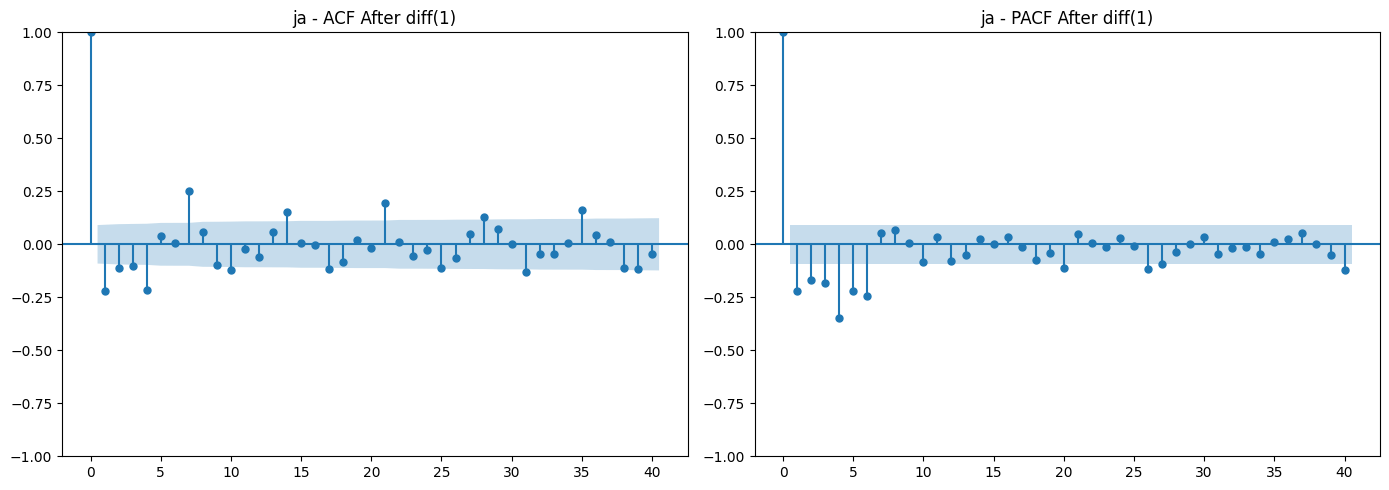


Detected p = 3
Detected q = 3


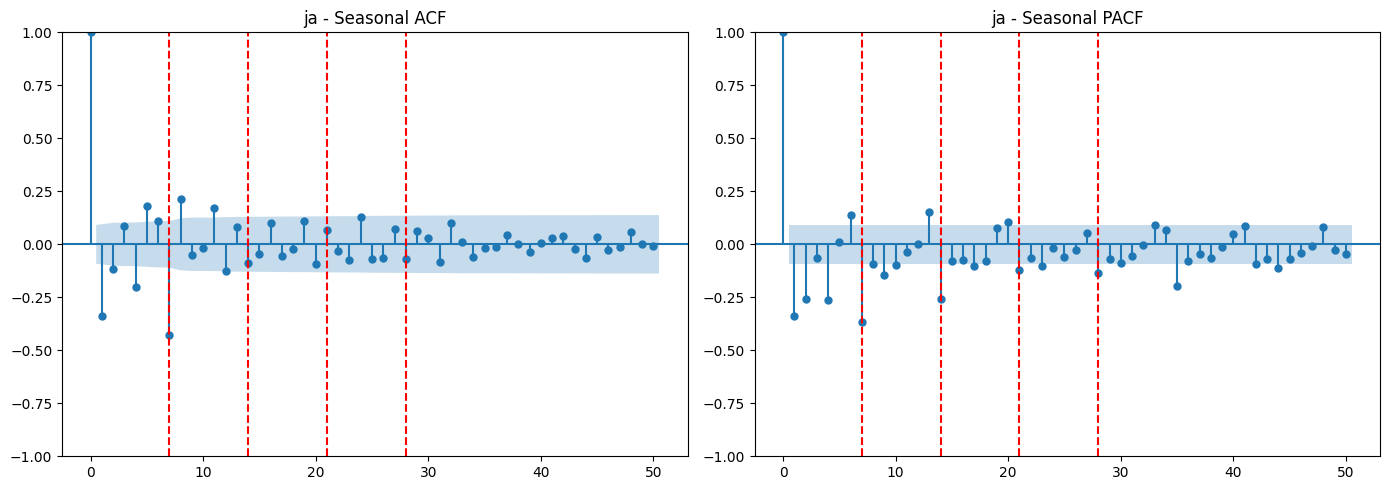


Detected P = 2
Detected D = 1
Detected Q = 1
Detected m = 7


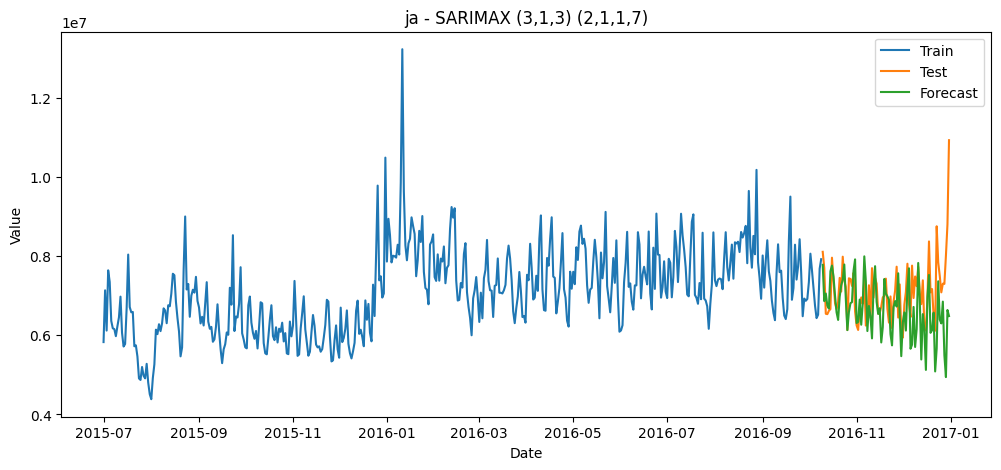

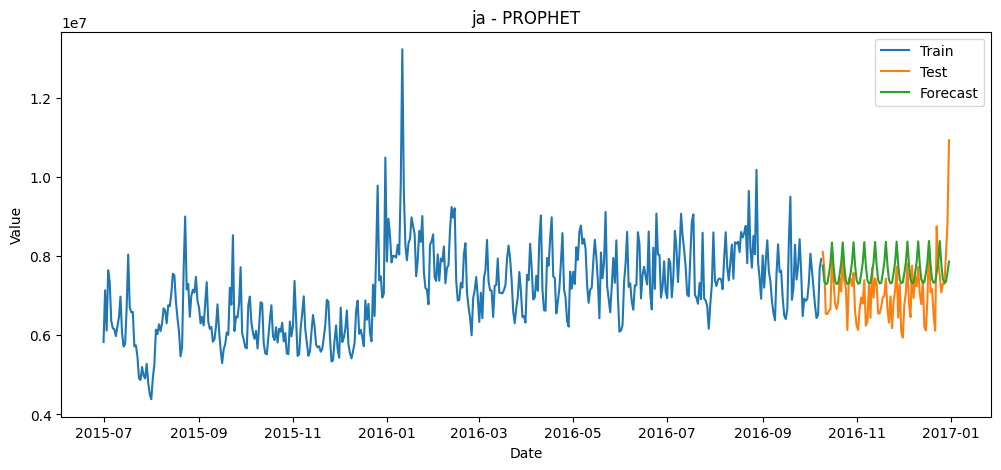

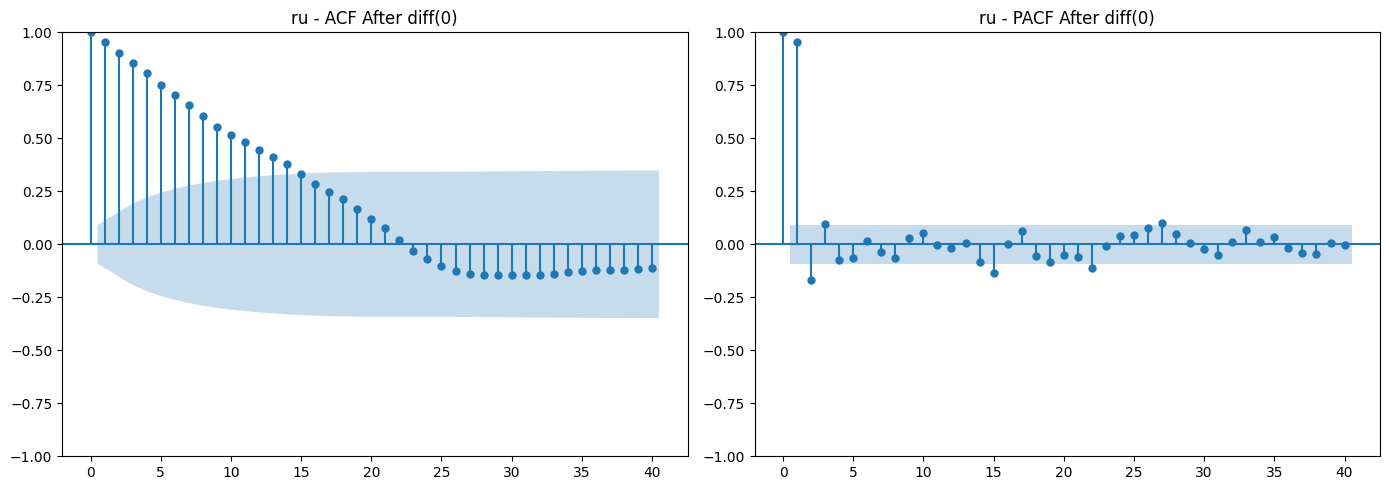


Detected p = 3
Detected q = 3


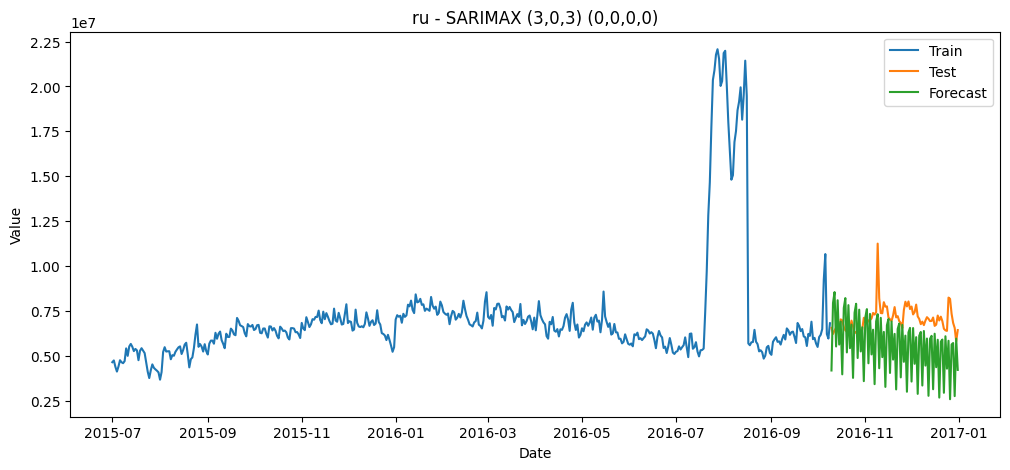

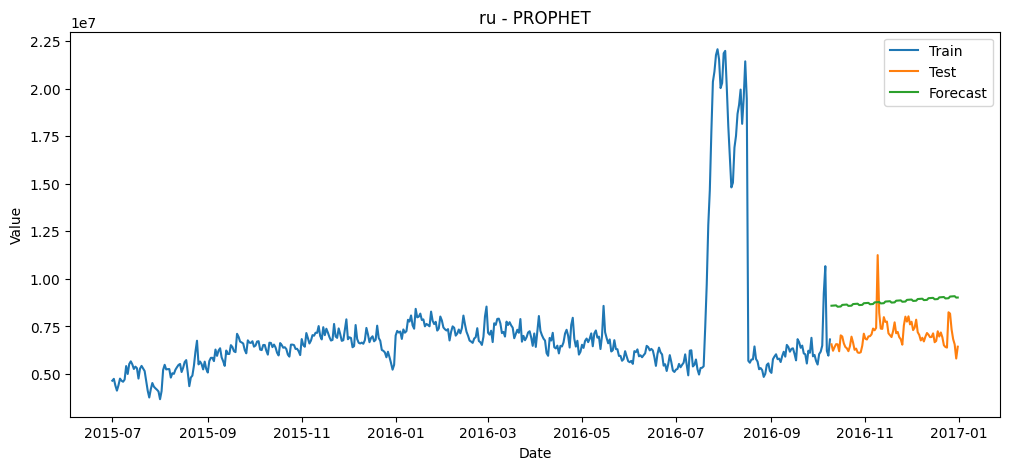

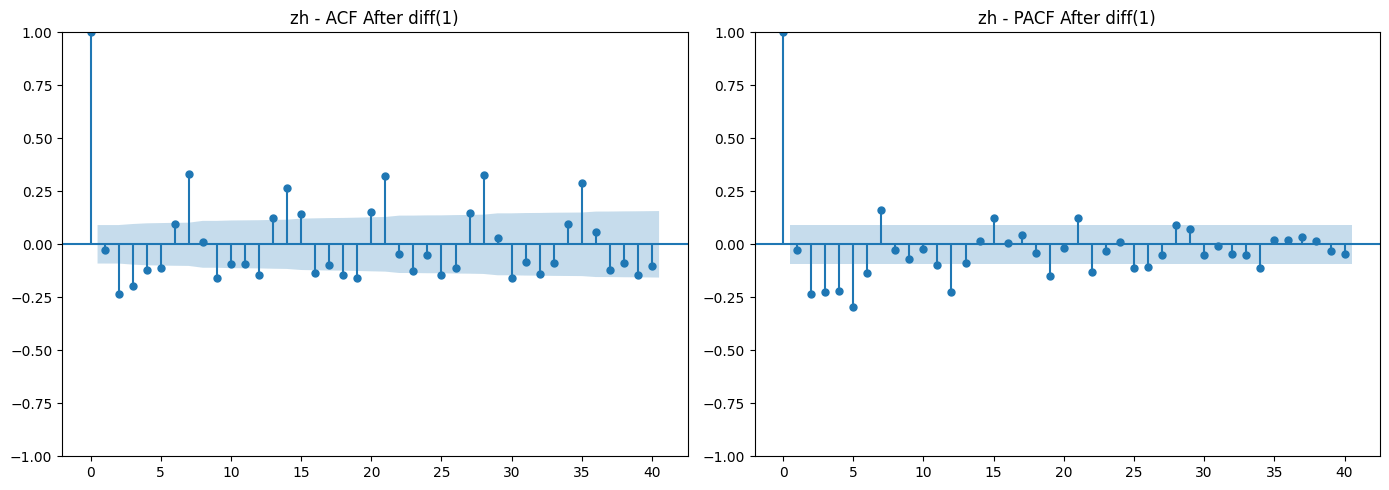


Detected p = 0
Detected q = 0


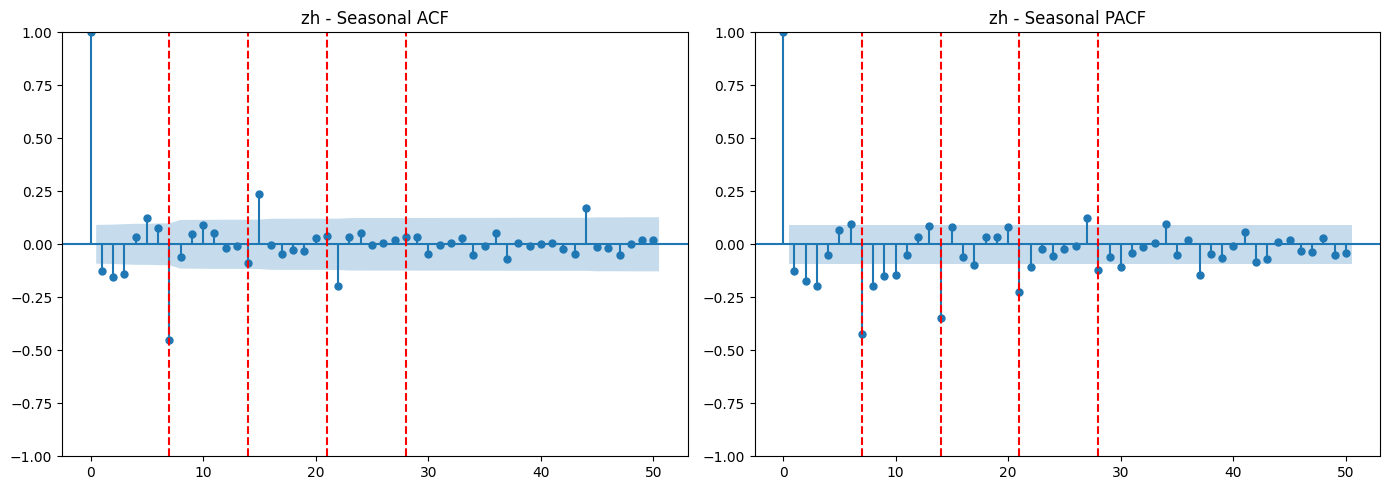


Detected P = 2
Detected D = 0
Detected Q = 1
Detected m = 7


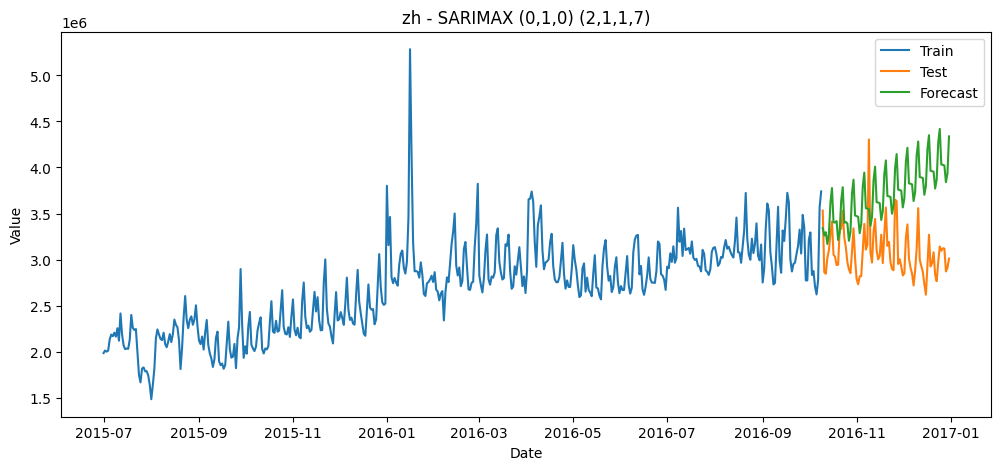

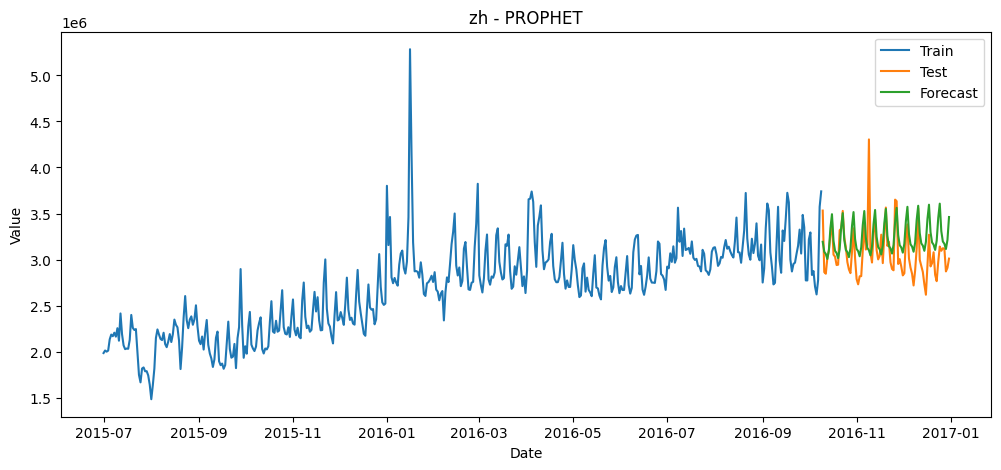

In [114]:
results_all = []
preds = {}

for lang in df_lang.columns:
    logger.info(f"Processing {lang}")

    df_tmp = df_lang[lang].rename('visits_count')

    train = df_tmp.iloc[:split_idx]
    test = df_tmp.iloc[split_idx:]

    # ============
    # COMMON EXOG
    # ============

    if exog_train is not None:
        exog_train_lang = (
            exog_train
            .loc[train.index]
            .copy()
        )

    else:
        exog_train_lang = None

    if exog_test is not None:
        exog_test_lang = (
            exog_test
            .loc[test.index]
            .copy()
        )

    else:
        exog_test_lang = None

    # =================================
    # ADD LANGUAGE SPECIFIC EXTRA EXOG
    # =================================

    if lang in extra_exog_train_dict:

        extra_train = (
            extra_exog_train_dict[lang]
            .loc[train.index]
        )

        if exog_train_lang is None:
            exog_train_lang = (
                extra_train.copy()
            )

        else:
            exog_train_lang = pd.concat(
                [
                    exog_train_lang,
                    extra_train
                ],
                axis=1
            )

    if lang in extra_exog_test_dict:
        extra_test = (
            extra_exog_test_dict[lang]
            .loc[test.index]
        )

        if exog_test_lang is None:
            exog_test_lang = (
                extra_test.copy()
            )
        else:
            exog_test_lang = pd.concat(
                [
                    exog_test_lang,
                    extra_test
                ],
                axis=1
            )

    # =========================
    # REMOVE DUPLICATE COLUMNS
    # =========================

    if exog_train_lang is not None:
        exog_train_lang = (
            exog_train_lang
            .loc[
                :,
                ~exog_train_lang.columns.duplicated()
            ]
        )

    if exog_test_lang is not None:
        exog_test_lang = (
            exog_test_lang
            .loc[
                :,
                ~exog_test_lang.columns.duplicated()
            ]
        )

    # ==========
    # EXOG COLS
    # ==========

    if exog_train_lang is not None:
        exog_cols = (
            exog_train_lang.columns
            .tolist()
        )

    else:
        exog_cols = []

    # =============
    # DIFFERENCING
    # =============

    d = find_d(train)

    if d > 0:
        series_diff = train.diff(d).dropna()
    else:
        series_diff = train.copy()

    # ============
    # SEASONALITY
    # ============

    m = find_seasonal_period(series_diff)

    # ====
    # p q
    # ====

    p, q = extract_pq(
        series_diff,
        seasonal_period=max(m, 1),
        lang=lang,
        d=d
    )

    # ====
    # P Q
    # ====

    if m > 1:
        seasonal_diff = (
            series_diff
            .diff(m)
            .dropna()
        )

        P, Q = extract_seasonal_pq(
            seasonal_diff,
            seasonal_period=m,
            lang=lang,
            D=D
        )

        D = 1

    else:
        P, Q, D = 0, 0, 0

    # ===============
    # OVERLAP REMOVAL
    # ===============

    if m > 1:
        seasonal_ar_lags = set(
            m * i
            for i in range(1, P + 1)
        )

        seasonal_ma_lags = set(
            m * i
            for i in range(1, Q + 1)
        )

        while p in seasonal_ar_lags and p > 0:
            p -= 1

        while q in seasonal_ma_lags and q > 0:
            q -= 1

    logger.info(
        f"{lang}: "
        f"({p},{d},{q}) "
        f"({P},{D},{Q},{m})"
    )

    # ==============
    # SEASONAL ORDER
    # ==============

    if m > 1:
        seasonal_order = (
            P,
            D,
            Q,
            m
        )
    else:
        seasonal_order = (
            0,
            0,
            0,
            0
        )

    # ========
    # SARIMAX
    # ========

    model = SARIMAX(
        train,
        exog=exog_train_lang.loc[train.index],
        order=(p, d, q),
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    forecast = model_fit.forecast(
        steps=len(test),
        exog=exog_test_lang.loc[test.index]
    )

    plot_forecast(
        train,
        test,
        forecast,
        (
            f'{lang} - '
            f'SARIMAX '
            f'({p},{d},{q}) '
            f'({P},{D},{Q},{m})'
        )
    )

    sarimax_mape = safe_mape(
        test,
        forecast
    )
    # =======
    # PROPHET
    # =======

    train_prophet = pd.DataFrame({
        'ds': train.index,
        'y': train.values
    })

    test_prophet = pd.DataFrame({
        'ds': test.index,
        'y': test.values
    })

    for col in exog_train_lang.columns:
        train_prophet[col] = (
            exog_train_lang
            .loc[train.index][col]
            .values
        )

        test_prophet[col] = (
            exog_test_lang
            .loc[test.index][col]
            .values
        )

    best_prophet = tune_prophet(
        train_prophet,
        exog_train_lang.columns,
        seasonal_period=max(m, 1)
    )

    prophet_model = Prophet(
        changepoint_prior_scale=
        best_prophet[
            'changepoint_prior_scale'
        ],

        seasonality_prior_scale=
        best_prophet[
            'seasonality_prior_scale'
        ],

        seasonality_mode=
        best_prophet[
            'seasonality_mode'
        ],

        n_changepoints=
        best_prophet[
            'n_changepoints'
        ],

        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        mcmc_samples=0
    )

    for col in exog_train_lang.columns:
        prophet_model.add_regressor(col)

    if m > 1:
        prophet_model.add_seasonality(
            name='custom',
            period=m,
            fourier_order=
            best_prophet['fourier_order']
        )

    prophet_model.fit(train_prophet)
    future = test_prophet.drop(columns=['y'])
    prophet_fc = prophet_model.predict(future)
    prophet_pred = prophet_fc['yhat'].values

    plot_forecast(
        train,
        test,
        prophet_pred,
        (
            f'{lang} - '
            f'PROPHET'
        )
    )

    prophet_mape = safe_mape(
        test_prophet['y'],
        prophet_pred
    )

    # ===============
    # MODEL SELECTION
    # ===============

    model_scores = {
        'SARIMAX': sarimax_mape,
        'PROPHET': prophet_mape
    }

    best_model = min(
        model_scores,
        key=model_scores.get
    )

    logger.info(
        f"Best model for {lang}: "
        f"{best_model}"
    )

    if best_model == 'SARIMAX':
        preds[lang] = forecast
    else:
        preds[lang] = prophet_pred

    results_all.append({
        'language': lang,
        'p': p,
        'd': d,
        'q': q,
        'P': P,
        'D': D,
        'Q': Q,
        'm': m,
        'SARIMAX_MAPE': sarimax_mape,
        'PROPHET_MAPE': prophet_mape,
        'BEST_MODEL': best_model
    })

##7. Final LeaderBoard

In [115]:
pd.options.display.float_format = '{:.2f}'.format

In [116]:
results_df = pd.DataFrame(results_all)
results_df.sort_values(by='PROPHET_MAPE', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,language,p,d,q,P,D,Q,m,SARIMAX_MAPE,PROPHET_MAPE,BEST_MODEL
0,en,0,1,0,2,1,2,21,6.34,5.57,PROPHET
1,zh,0,1,0,2,1,1,7,21.88,7.08,PROPHET
2,ja,3,1,3,2,1,1,7,9.47,10.47,SARIMAX
3,fr,2,1,2,2,1,1,7,36.98,13.15,PROPHET
4,de,3,1,2,2,1,1,7,6.95,15.91,SARIMAX
5,es,3,0,3,2,1,2,7,16.87,17.04,SARIMAX
6,ru,3,0,3,0,0,0,0,26.16,26.68,SARIMAX
7,no_lang,2,0,3,0,0,0,0,67.30,30.67,PROPHET


All `mape` in above table are actually in `mape percentage` form i.e. `mape * 100`.


Forecasting Model Summary:
---
We compared SARIMAX and Prophet across 8 language segments using MAPE(%) (lower is better).

- Prophet performed better for English, Chinese, French, and No Language segments.
- SARIMAX performed better for Japanese, German, Spanish, and Russian segments.
- Prophet achieved the best overall accuracy for English (5.57% MAPE).
German showed strong SARIMAX performance (6.95% MAPE).
- "No Language" pages had the highest forecasting error, indicating unstable or noisy traffic patterns.
- Most models required first-order differencing (d=1) and weekly seasonality (m=7) to achieve stationarity and capture recurring patterns.

Recomendations:

- High-error segments may require manual review/intervention instead of fully automated forecasting, especially where data quality, volatility, or irregular patterns are present.
- Forecast accuracy could likely improve with better exogenous variables (external features), such as holidays, campaigns, events, traffic trends, or operational signals.

#Questionnaire:

##1. Defining the problem statements and where can this and modifications of this be used?

AdEase wants to forecast future Wikipedia page views across multiple languages and regions to optimize digital ad placement i.e. to place the right ads on the right pages at the right time.

Where This Can Be Used
1. Ad Placement Optimization
2. Dynamic Pricing( Airline/hotel demand forecasting)
3. Campaign Planning(E-commerce demand forecasting)
4. Capacity Planning(CDN traffic optimization)
5. Trend Detection(Stock market trend prediction)

Modification of this can be used in:

1. Real-Time Forecasting
2. Click Prediction / View Prediction
3. Personalized Advertising
    by combining

    `user demographics,
    browsing behavior,
    geography,
    device type,
    for targeted ads.`

4. Anomaly Detection


##2. Write 3 inferences you made from the data visualizations

1.
    - English pages should receive highest ad prioritization and forecasting focus due to massive traffic volume.

    - Mid-tier languages offer strong regional targeting opportunities.

    - Lower-volume languages may require more localized or niche ad strategies rather than broad campaigns.

2. Users primarily consume Wikipedia content on mobile/Desktop devices.
3. A substantial amount of page views are non-human(spiders) and unlikely to generate ad revenue.

##3. What does the decomposition of series do?

Time series decomposition breaks a series into its underlying components to help understand the structure and patterns in the data.

Typically, a series is decomposed into: Trend, Seasnoality, Residual(Noise)

##4. What level of differencing gave you a stationary series?

The series became stationary after first-order differencing (d = 1). This removed the trend component and stabilized the mean over time.

##5. Difference between arima, sarima & sarimax.

- ARIMA -> trend only

- SARIMA -> trend + seasonality

- SARIMAX -> trend + seasonality + external factors

    Example of exogenous variables in SARIMAX:
    ```holidays,
    campaigns,
    weather,
    traffic,
    promotions.

##6. Compare the number of views in different languages.

In [117]:
df_lang.sum(axis=0).sort_values(ascending=False)

,0
lang,
en,28379109049.00
es,4591504943.00
de,4335306137.00
ja,3909995594.00
ru,3889113328.00
fr,3025465669.00
zh,1512980151.00
no_lang,744891617.00


Human Traffic by Language
 - English (en) dominates with ~28.4B human page views.
 - Spanish (es), German (de), Japanese (ja), and Russian (ru) form the next major traffic groups with ~3.9–4.6B views.
 - French (fr) shows moderate traffic (~3.0B).
 - Chinese (zh) and “No Language” pages have the lowest human traffic volumes.

## 7. What other methods other than grid search would be suitable to get the model for all languages?

For multi-language forecasting, Bayesian optimization or Auto ARIMA is usually more scalable than brute-force grid search.